# Complete Analysis Pipeline: ZCI Computation

This notebook implements the complete **Zoobenthic Community Indicator (ZCI)** analysis pipeline, integrating all four analysis stages from the `zci` package:

## Pipeline Stages

1. **Stage 1: Contamination Assessment** (`zci.contamination_assessment`)
   - PCA-based pollution scoring from chemical variables
   - RDA validation of pollution gradients against species

2. **Stage 2: Taxa Assemblage on Reference Sites** (`zci.taxa_assemblage_in_refs`)
   - Reference site selection based on pollution scores
   - Hierarchical clustering of species composition
   - Cluster visualization and analysis

3. **Stage 3: Environment-Driven Taxa Clusters** (`zci.env_driven_taxa_clusters`)
   - RDA analysis linking environmental variables to taxa composition
   - LDA classification with Monte Carlo cross-validation
   - Prediction of non-reference site clusters

4. **Stage 4: Community Composition Ordination** (`zci.community_composition_measures`)
   - Cluster-specific PCA on transformed species data
   - ZCI calculation (compositional distance from reference)
   - Taxa loadings and ordination visualization

---

## Parameter Organization

All parameters are organized into categories:
- **KEY_PARAMS**: Explicitly assigned core parameters for each stage
- **MODEL_PARAMS**: Statistical model settings (nested into KEY_PARAMS)
- **FIGURE_PARAMS**: Visualization settings (nested into KEY_PARAMS)
- **DATA_PARAMS**: Data paths and column names

In [282]:
# =============================================================================
# IMPORTS AND SETUP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ Base imports loaded successfully!")

✓ Base imports loaded successfully!


## Configuration: Parameter Pool

The parameters are organized hierarchically:
1. **KEY_PARAMS** - Core parameters that are explicitly assigned and most commonly modified
2. **MODEL_PARAMS** - Statistical model settings (nested into KEY_PARAMS where appropriate)
3. **FIGURE_PARAMS** - All visualization settings
4. **DATA_PARAMS** - Data paths and column specifications

In [283]:
# =============================================================================
# PARAMETER CONFIGURATION - HIERARCHICAL ORGANIZATION
# =============================================================================

# -----------------------------------------------------------------------------
# DATA PARAMETERS - Input data paths and column specifications
# -----------------------------------------------------------------------------
DATA_PARAMS = {
    'data_path': "../data/processed/complete_env_taxa_chemical.xlsx",
    'sheet_name': "all_data_merged",
    'pollution_column': 'Pollution_Score',      # Column name for pollution scores
    'cluster_column': 'clusters',               # Column name for cluster labels
    'ref_column': 'if_ref',                     # Column for reference site indicator
}

# =============================================================================
# KEY PARAMETERS - EXPLICITLY ASSIGNED CORE PARAMETERS (Simplified)
# =============================================================================
# These are the most important parameters that users typically need to modify.
# Nested within each stage are visualization, model, and output settings.
# =============================================================================

KEY_PARAMS = {
    # =========================================================================
    # STAGE 1: Contamination Assessment
    # =========================================================================
    'stage1': {
        # --- CORE PARAMETERS ---
        'transform_method': 'log_z_score',      # 'log_z_score', 'robust_scaler'
        'pc_weights': {
            'PC1': 2.0, 'PC2': 1.0, 'PC3': 2.0,
            'PC4': 0.0, 'PC5': 1.0, 'PC6': 1.0,
        },
        'save_individual_pcs': True,
        
        # --- MODEL SETTINGS ---
        'standardize_pca_scores': True,
        'run_rda_validation': True,
        'rda_percentile_threshold': 40,
    },
    
    # =========================================================================
    # STAGE 2: Taxa Assemblage on Reference Sites
    # =========================================================================
    'stage2': {
        # --- CORE PARAMETERS ---
        'reference_percentile': 40,
        'species_transformation': 'hellinger',
        'n_clusters': 2,
        'top_n_taxa': 16,
        
        'env_variables': [
            'Measured Depth (m)',
            'Velocity  at bottom (m/sec)_Imputed',
            'Water DO Bottom (mg/L)',
            'Temperature (oC)',
            'MPS (Phi)',
            'LOI (%)'
        ],
        
        # --- MODEL SETTINGS ---
        'linkage_method': 'ward',
        
        # --- VISUALIZATION SETTINGS ---
        'create_cluster_visualization': True,
        'create_dendrogram_comparison': True,
        'create_ward_analysis': True,
        'create_comparison_plots': True,
        'label_positions': [90, 250, 380],
    },
    
    # =========================================================================
    # STAGE 3: Environment-Driven Taxa Clusters (RDA + LDA)
    # =========================================================================
    'stage3': {
        # --- CORE PARAMETERS ---
        'rda_n_permutations': 999,
        'lda_n_iterations': 1000,
        'taxa_transformation': 'hellinger',
        'top_n_taxa_rda': None,
        'lda_log_transform_env': False,
        
        # --- MODEL SETTINGS ---
        'rda_log_transform_env': False,
        'rda_standardize_env': True,
        'lda_standardize_env': True,
        'lda_test_size': 0.2,
        'random_state': 42,
        
        # --- VISUALIZATION SETTINGS ---
        'rda_arrow_scale': 0.5,
        'rda_species_scale': 0.5,
        'rda_figsize': (14, 10),
        'lda_arrow_scale': 2,
        'lda_cv_figsize': (14, 9),
    },
    
    # =========================================================================
    # STAGE 4: Community Composition Ordination (PCA-based ZCI)
    # =========================================================================
    'stage4': {
        # --- CORE PARAMETERS ---
        'taxa_transformation': 'hellinger',
        'training_percentile': 100.0,
        'top_n_taxa': 16,
        
        # PC specifications (1-indexed)
        'taxa_loadings_pcs': {
            0: (1, 2, 3, 4, 5),
            1: (1, 2, 3, 4, 5, 6),
            2: (1, 2, 3, 4),
        },
        'zci_pc_planes': None,
        
        # ZCI Method
        'zci_method': 'least_pollution_threshold',
        'least_pollution_threshold': 15,
        
        # --- MODEL SETTINGS ---
        'variance_threshold': 0.70,
        'pc_variance_threshold': 5.0,
        'normalize_pcs': False,
        'pollution_pc_prefix': 'Pollution_PC',
        'use_consistent_taxa_order': True,
        'random_state': 42,
        
        # --- VISUALIZATION SETTINGS ---
        'create_taxa_loadings_plot': True,
        'create_pc_loadings_plot': True,
        'create_ordination_plot': True,
        'create_zci_plot': True,
        'create_pc_regression_plot': True,
        'create_pollution_vs_species_pc_plot': True,
        'create_comprehensive_plot': False,
        'pc_plane': (1, 2),
        'pc_loadings_top_n_taxa': None,
        'pc_loadings_show_values': False,
        'taxa_loadings_figsize': (14, 12),
        'ordination_figsize': (18, 6),
        'zci_figsize': (16, 10),
    },
    
    # =========================================================================
    # GENERAL SETTINGS
    # =========================================================================
    'verbose': True,
    'random_state': 42,
}

print("=" * 80)
print("✓ PARAMETERS CONFIGURED")
print("=" * 80)

✓ PARAMETERS CONFIGURED


In [284]:
# =============================================================================
# OUTPUT PARAMETERS - Save paths and settings
# =============================================================================

from datetime import datetime

# Generate timestamp for this run
RUN_TIMESTAMP = datetime.now().strftime("%m_%d_%H_%M")

# Base results directory (relative to notebook location)
RESULTS_DIR = "../results"

# Output configuration
OUTPUT_PARAMS = {
    'save_figures': True,                       # Save all figures
    'save_tables': True,                        # Save all tables
    'save_parameters': True,                    # Save parameter configuration
    'figure_formats': ['png'],                  # Output formats
    'figure_dpi': 300,                          # Resolution
    'timestamp': RUN_TIMESTAMP,
}

# Construct full paths for each stage
FIGURE_PATHS = {
    1: f"{RESULTS_DIR}/figures/01_contamination_assessment",
    2: f"{RESULTS_DIR}/figures/02_taxa_assemblage_in_refs",
    3: f"{RESULTS_DIR}/figures/03_env_driven_taxa_clusters",
    4: f"{RESULTS_DIR}/figures/04_community_composition_measures",
}

TABLE_PATHS = {
    1: f"{RESULTS_DIR}/tables/01_contamination_assessment",
    2: f"{RESULTS_DIR}/tables/02_taxa_assemblage_in_refs",
    3: f"{RESULTS_DIR}/tables/03_env_driven_taxa_clusters",
    4: f"{RESULTS_DIR}/tables/04_community_composition_measures",
}

print("✓ Output parameters configured")
print(f"  - Run timestamp: {RUN_TIMESTAMP}")
print(f"  - Save figures: {OUTPUT_PARAMS['save_figures']}")
print(f"  - Save tables: {OUTPUT_PARAMS['save_tables']}")

✓ Output parameters configured
  - Run timestamp: 01_15_15_06
  - Save figures: True
  - Save tables: True


---

## Stage 1: Contamination Assessment

**Objective**: Compute pollution scores from chemical variables using PCA-based weighted scoring.

**Key Parameters**:
- `transform_method`: How to transform raw pollution data before PCA
- `pc_weights`: Weights for combining principal components into final score


STAGE 1: CONTAMINATION ASSESSMENT
✓ Loaded data: 104 sites, 59 variables
CONTAMINATION ASSESSMENT PIPELINE

[Step 1/7] Extracting and preparing pollution data...
  ✓ Extracted 30 pollution variables from 104 sites

[Step 2/7] Applying transformation (method: log_z_score)...
  ✓ Applied log transformation (except As, Bi)
  ✓ Applied z-score standardization

[Step 3/7] Ordering variables by hierarchical clustering...
  ✓ Variables reordered by similarity

[Step 4/7] Performing PCA on transformed pollution data...


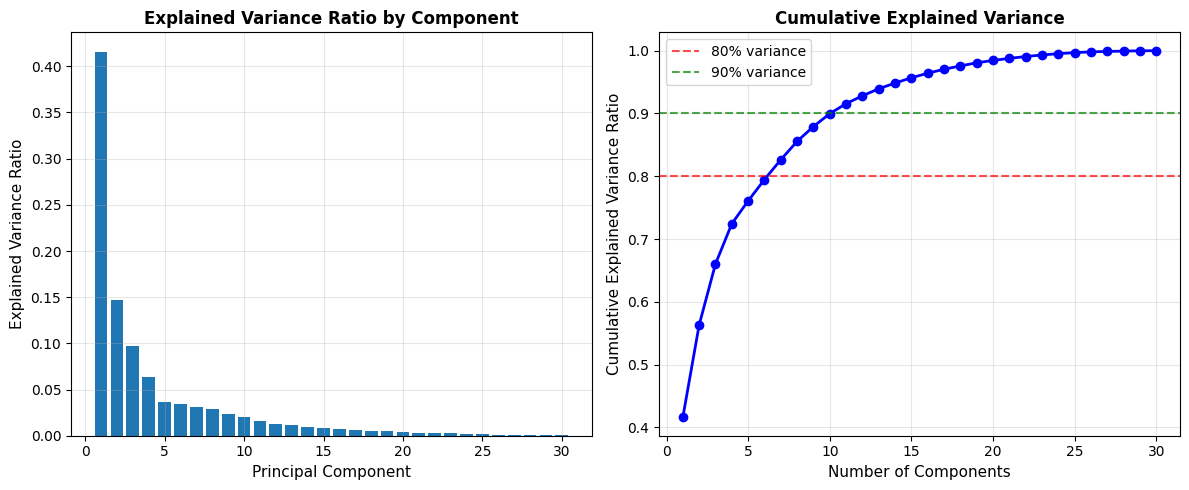

  ✓ Extracted 6 principal components
  ✓ PC loadings shape: (30, 6)
  ✓ PC scores shape: (104, 6)
  ✓ PC scores standardized (mean=0, std=1)

[Step 5/7] Creating visualizations...
  ✓ Ridge plot of PC loadings created

[Step 6/7] Running RDA validation (percentile threshold: 40)...
Hellinger transformation completed.
Original taxa data shape: (104, 16)

Percentile threshold: 40th percentile = -0.8306
Number of reference sites: 42
Number of contaminated sites: 62

Reference taxa data shape: (42, 16)
Reference habitat (PC scores) data shape: (42, 6)

Fitting RDA model...

✓ RDA triplot created successfully!
✓ RDA1 + RDA2 explain 58.95% of constrained variance
  ✓ RDA validation completed

[Step 7/7] Computing weighted pollution scores and merging into data...
  ✓ Using custom weights: {'PC1': 2.0, 'PC2': 1.0, 'PC3': 2.0, 'PC4': 0.0, 'PC5': 1.0, 'PC6': 1.0}
  ✓ Pollution scores added to data
  ✓ Multi-index column: ('pollution', 'weighted', 'SumRel')
  ✓ Raw data column: 'Pollution_Score'

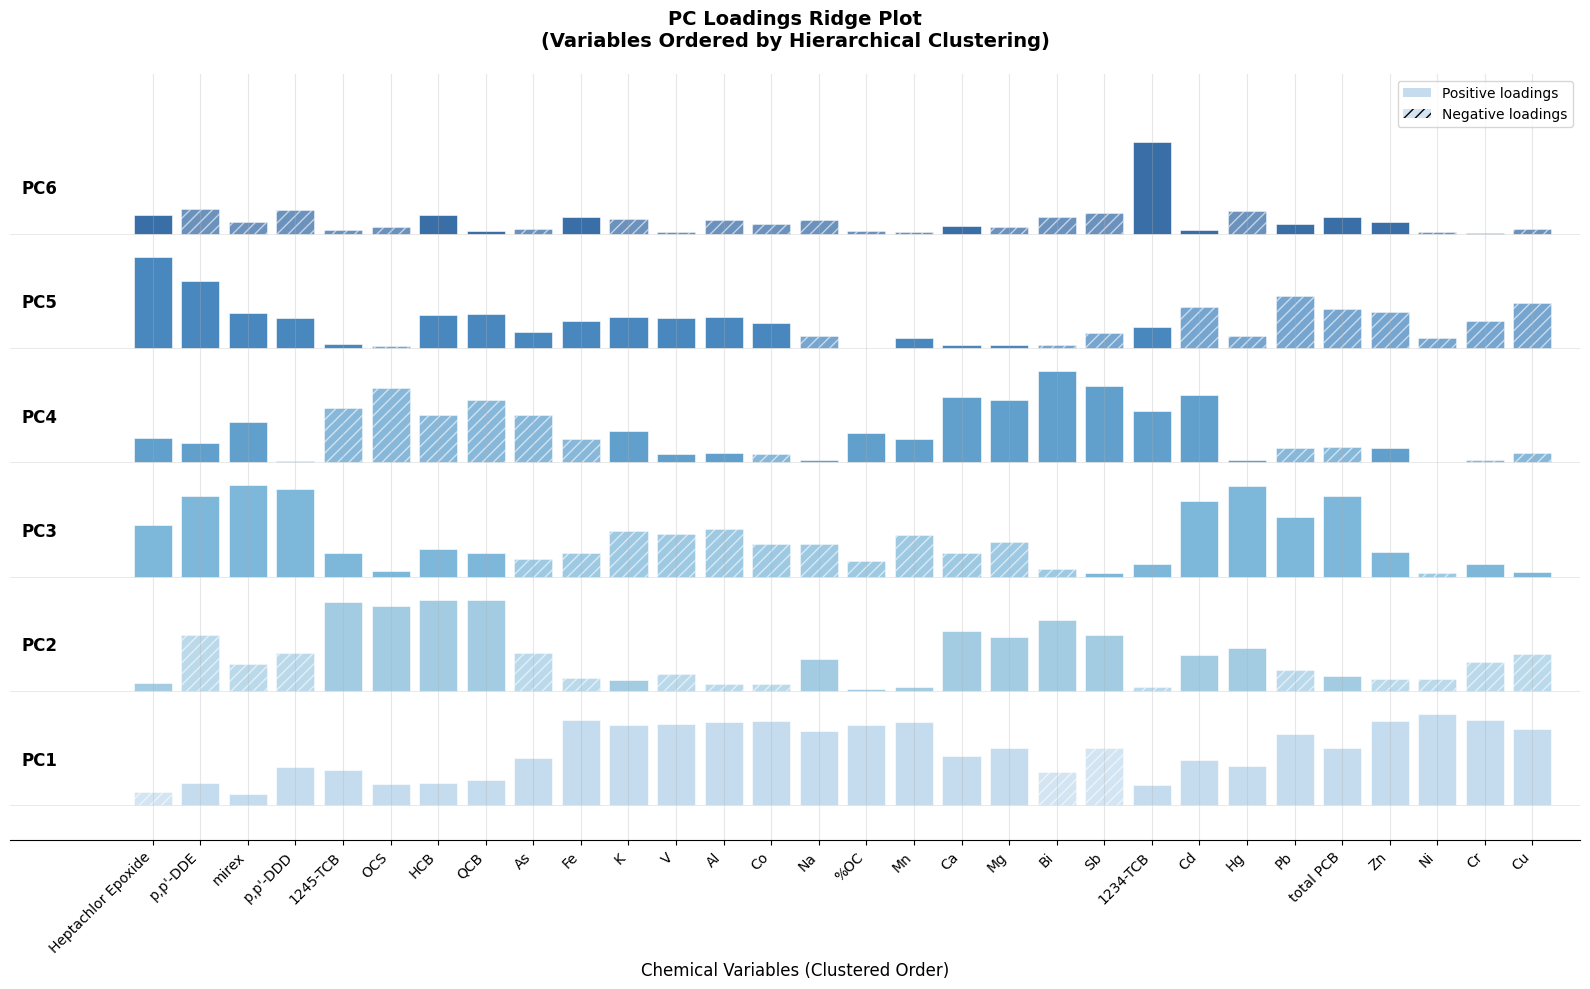

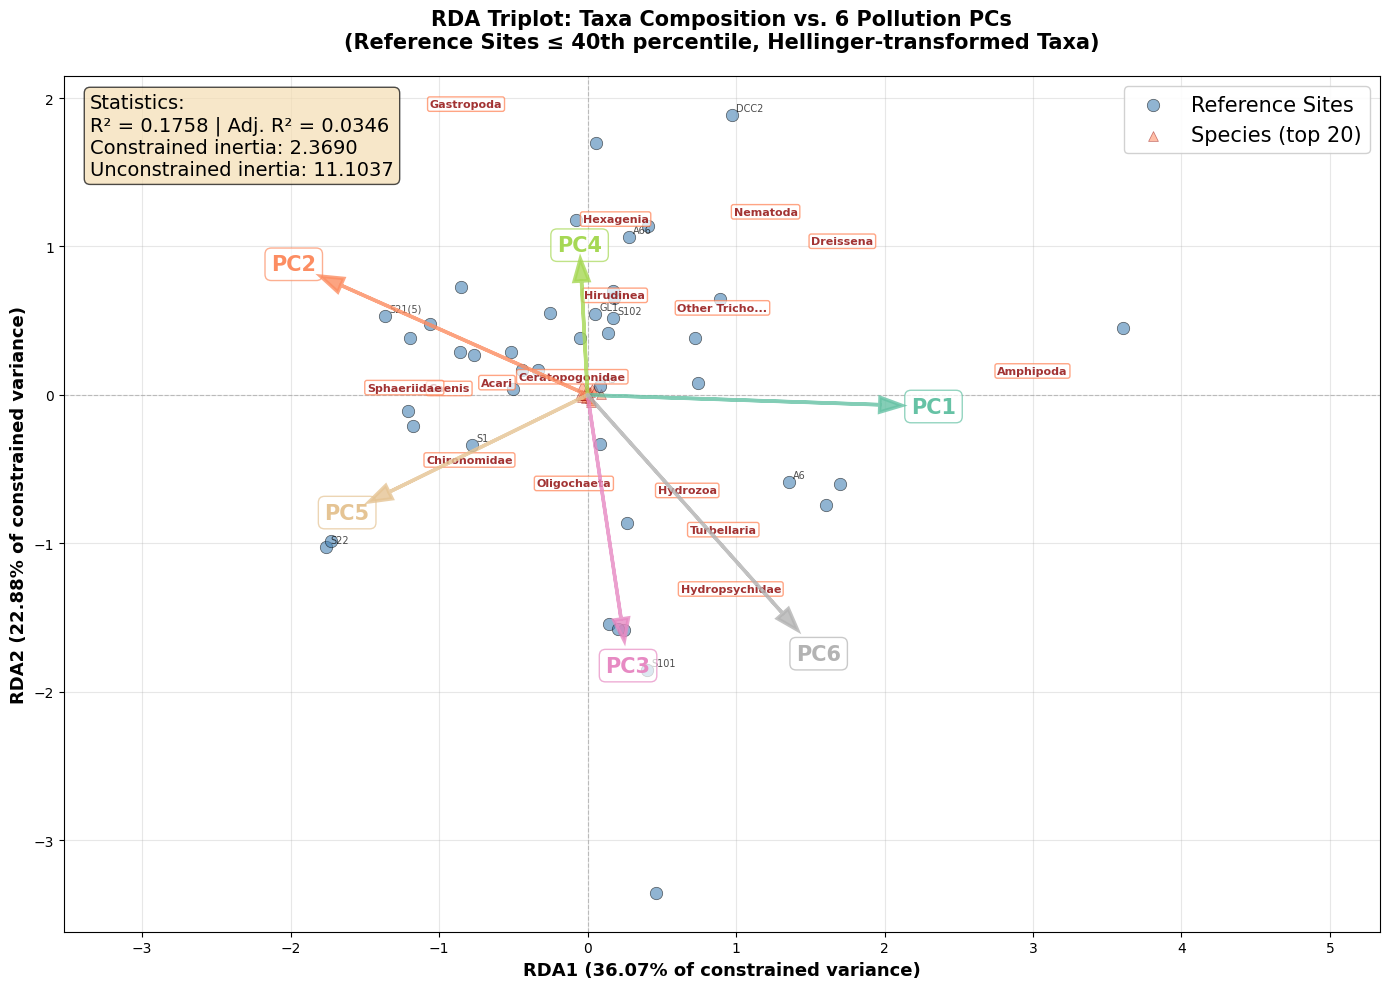

In [285]:
# =============================================================================
# STAGE 1: CONTAMINATION ASSESSMENT
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 1: CONTAMINATION ASSESSMENT")
print("=" * 80)

# Load data
data_input = pd.read_excel(
    DATA_PARAMS['data_path'],
    sheet_name=DATA_PARAMS['sheet_name'],
    header=[0, 1, 2],
    index_col=0
)
print(f"✓ Loaded data: {data_input.shape[0]} sites, {data_input.shape[1]} variables")

# Reload module to pick up changes
import importlib
import sys
modules_to_remove = [key for key in sys.modules.keys() if 'zci.contamination_assessment' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

# Import and run contamination assessment pipeline
from zci.contamination_assessment import pipeline as contamination_pipeline

cfg_s1 = KEY_PARAMS['stage1']

# Determine save path
save_path_s1 = FIGURE_PATHS[1] if OUTPUT_PARAMS['save_figures'] else None

stage1_results = contamination_pipeline.contamination_assessment_pipeline(
    data_input,
    transform_method=cfg_s1['transform_method'],
    standardize_pca_scores=cfg_s1['standardize_pca_scores'],
    pc_weights=cfg_s1['pc_weights'],
    run_rda_validation=cfg_s1['run_rda_validation'],
    rda_percentile_threshold=cfg_s1['rda_percentile_threshold'],
    save_individual_pcs=cfg_s1['save_individual_pcs'],
    save_path=save_path_s1,
)

# Extract outputs
raw_data_s1 = stage1_results['raw_data']
multiindex_data_s1 = stage1_results['multiindex_data']

print(f"\n✓ Stage 1 Complete!")
print(f"  - Pollution scores range: [{raw_data_s1['Pollution_Score'].min():.2f}, {raw_data_s1['Pollution_Score'].max():.2f}]")

# Verify individual PCs
pollution_pc_cols = [c for c in raw_data_s1.columns if c.startswith('Pollution_PC')]
print(f"  - Individual pollution PCs saved: {pollution_pc_cols}")

# Report saved figures
if 'figures' in stage1_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage1_results['figures'])} to {save_path_s1}")

---

## Stage 2: Taxa Assemblage on Reference Sites

**Objective**: Identify reference sites (least polluted) and cluster them by species composition to define habitat types.

**Key Parameters**:
- `reference_percentile`: Bottom X% of sites selected as reference
- `species_transformation`: How to transform species data before clustering
- `n_clusters`: Number of habitat clusters to identify


STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES
REFERENCE SITES TAXA ASSEMBLAGE PIPELINE

Configuration:
  - Reference percentile: 40%
  - Species transformation: hellinger
  - Linkage method: Ward's
  - Number of clusters: 2
  - Top taxa to display: 16
  - Run Box-Cox ANOVA: False
  - Save path: ../results/figures/02_taxa_assemblage_in_refs

STEP 1: Imputing velocity values...
VELOCITY IMPUTATION FOR SCDRS SITES

Detroit River baseline: 0.188 m/s (median of 18 sites)

[Lake St. Clair Imputation]
  LSC sites: 66
  Delta zone sites: 34
  Velocity range: -0.054 to 0.329 m/s
  Median velocity (all): 0.045 m/s
  Median velocity (delta): 0.094 m/s

[St. Clair River Imputation]
  SCR sites: 20
  Velocity range: 0.085 to 0.306 m/s
  Median velocity: 0.176 m/s
  Ratio to DR median: 0.94x

Creating visualizations...

IMPUTATION COMPLETED SUCCESSFULLY

Summary:
  Total sites: 104
  Sites with imputed values: 86
  Sites with recorded values: 18
  ✓ Velocity imputation complete

STEP 2: Selecting ref

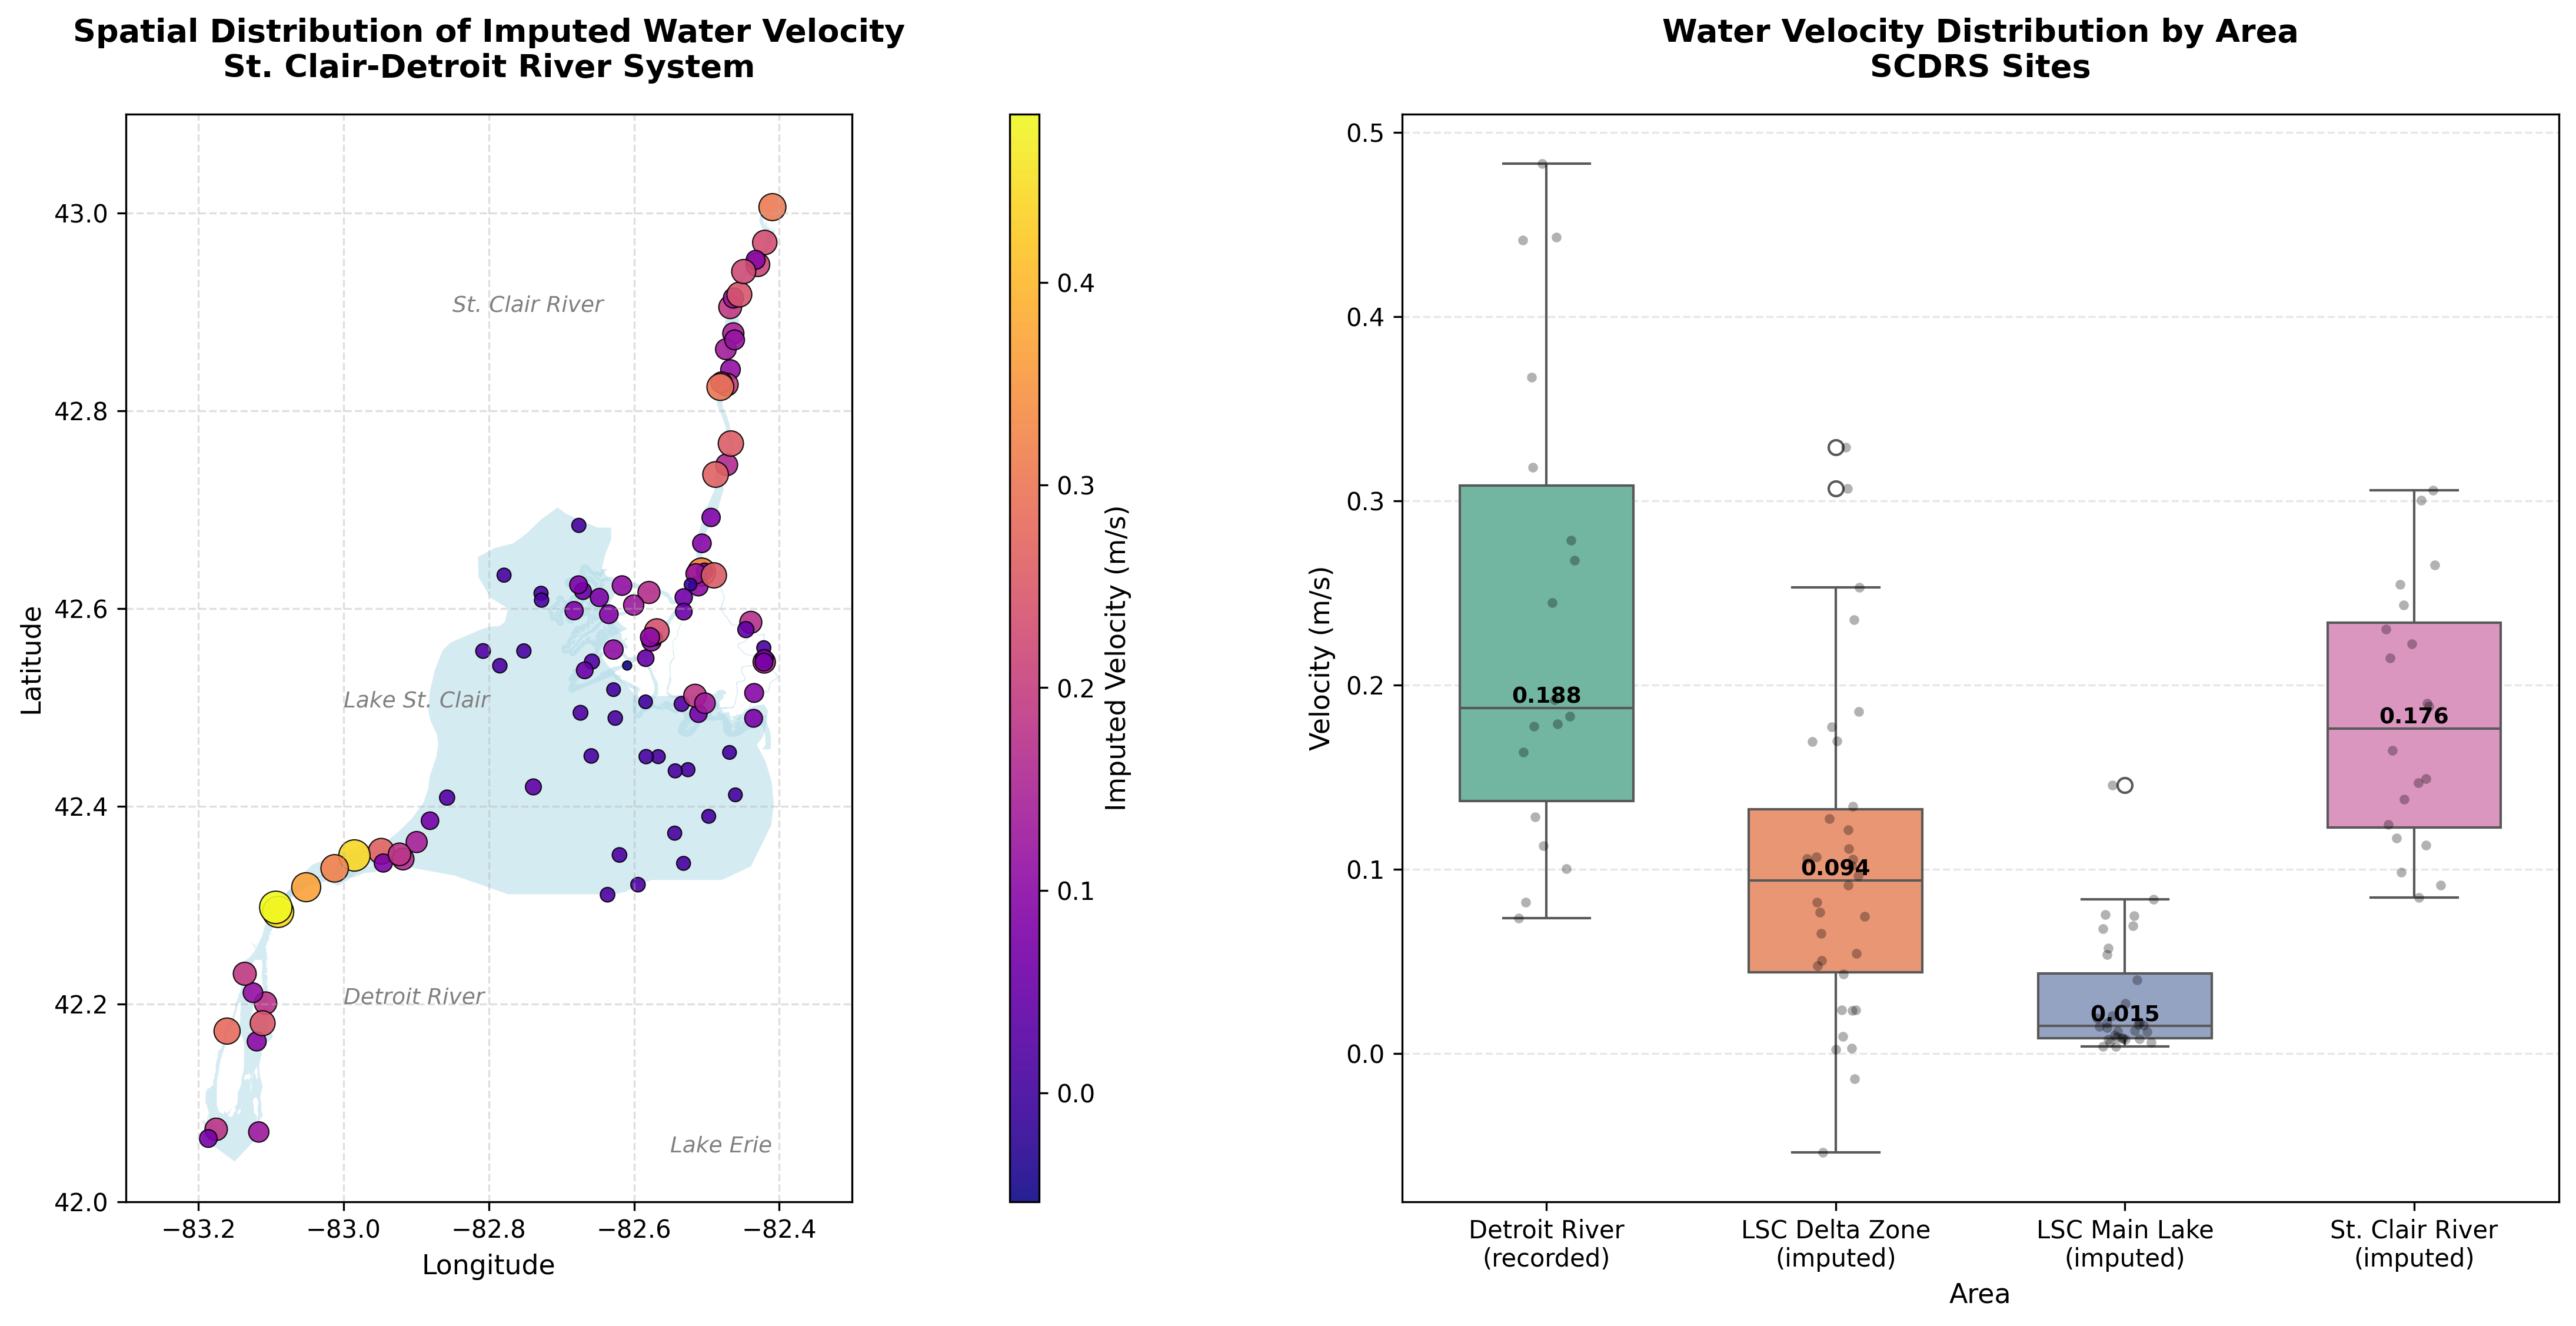

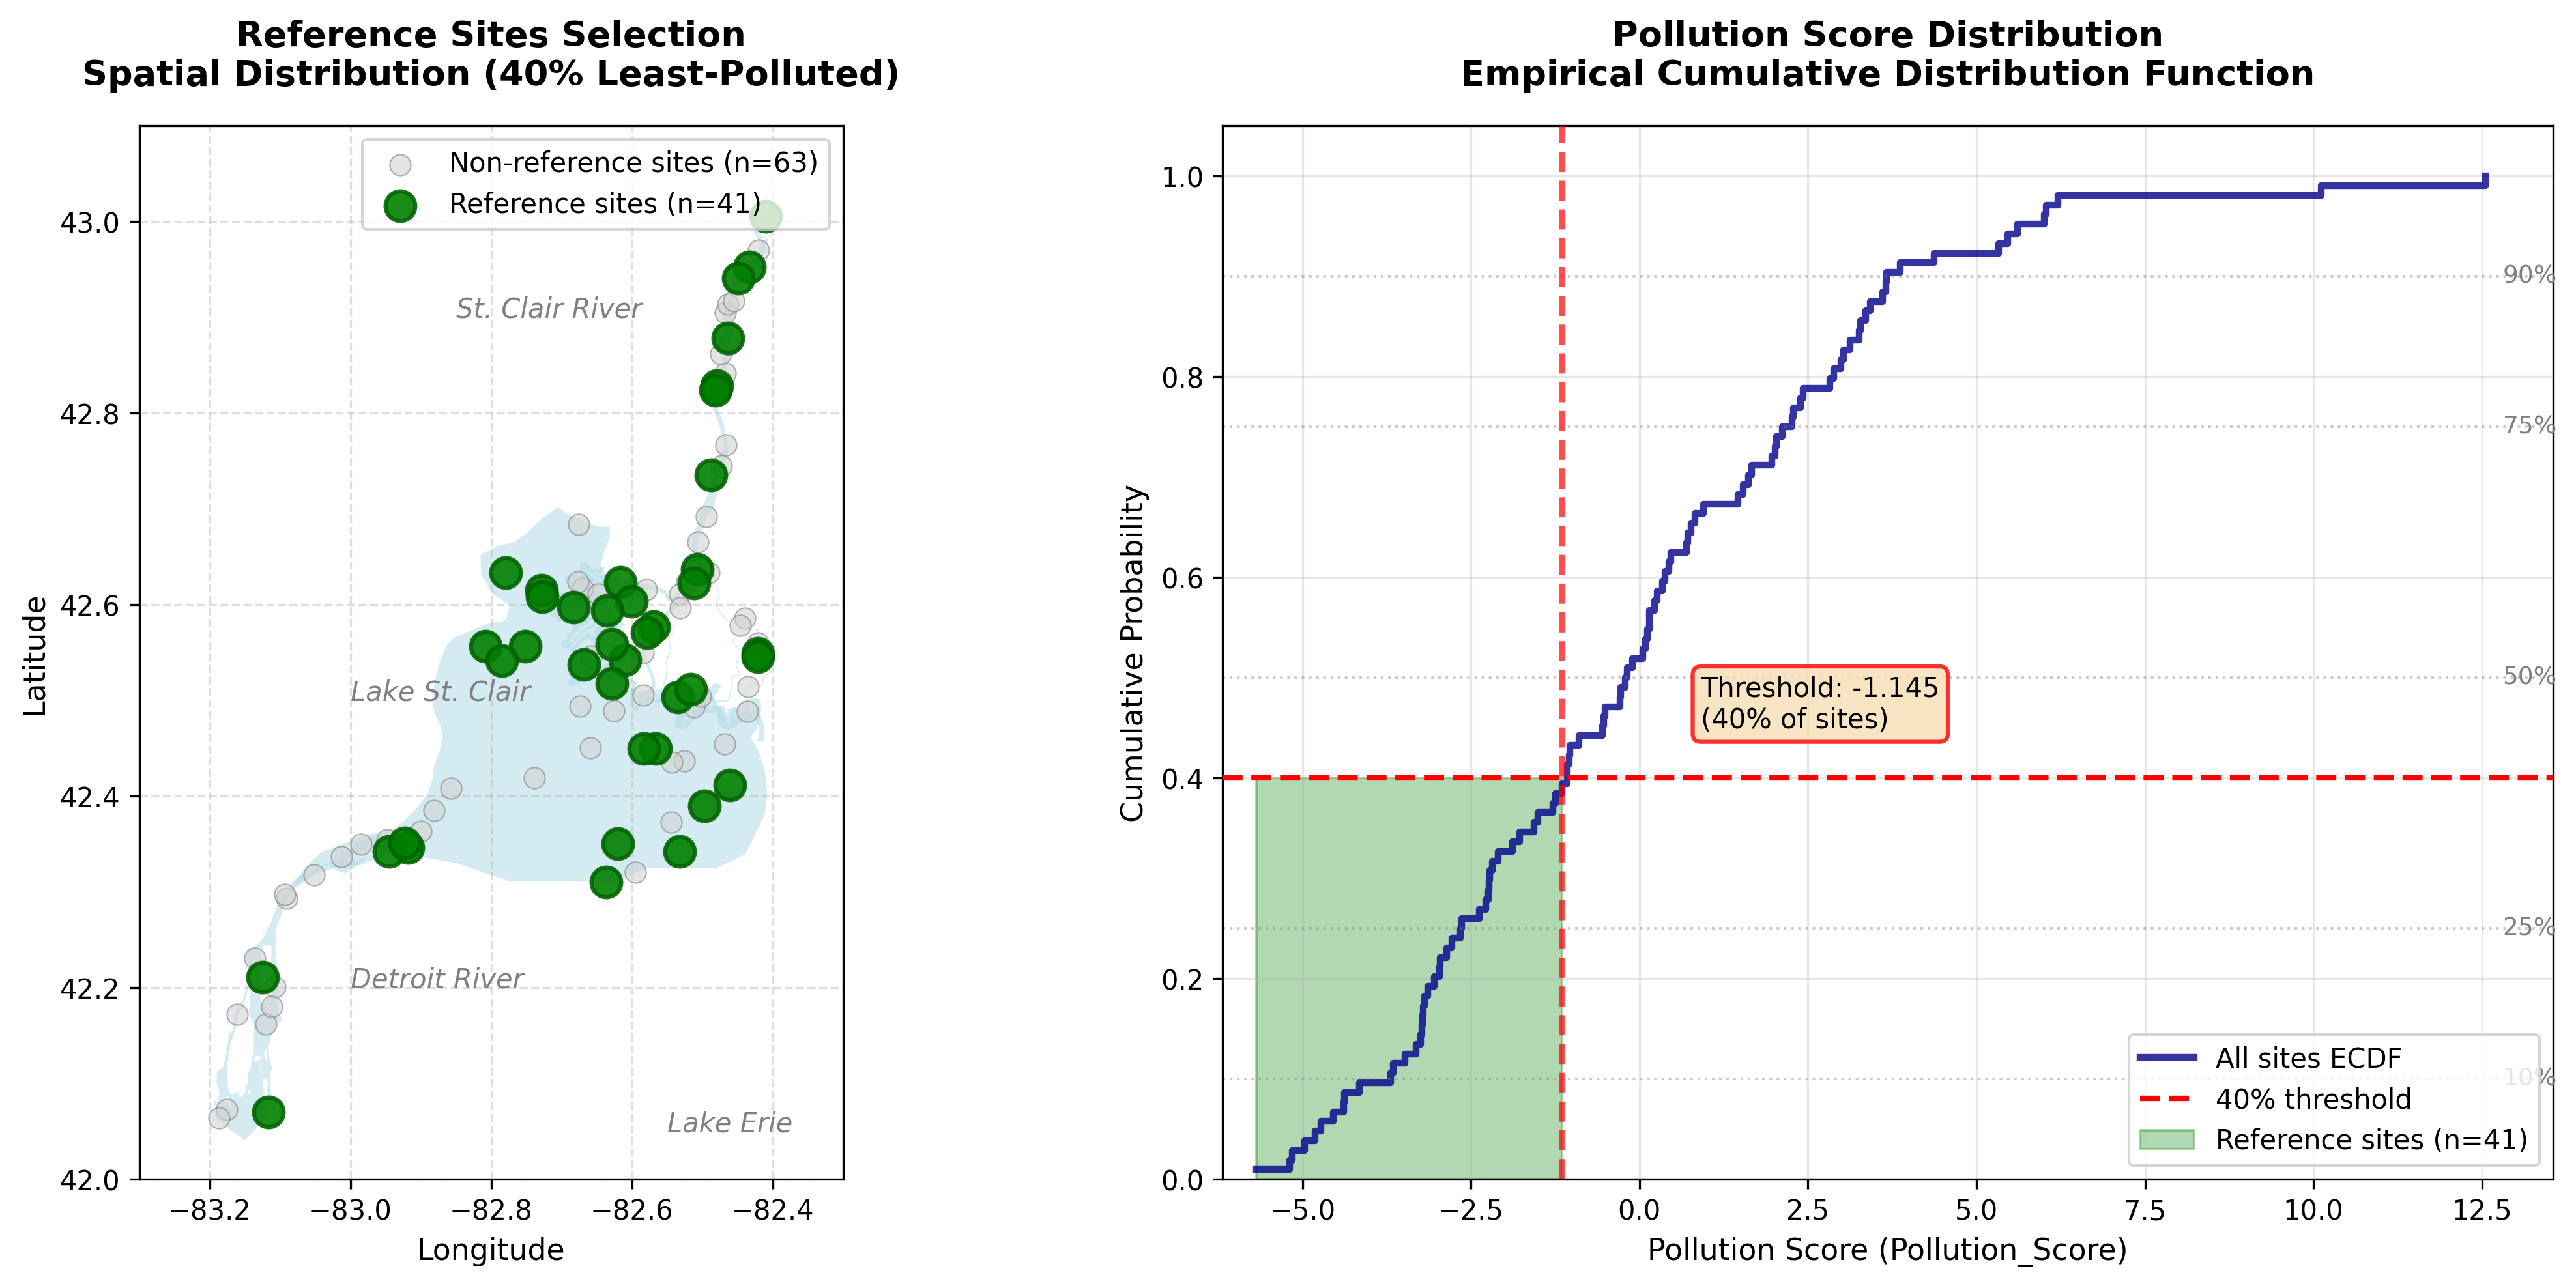

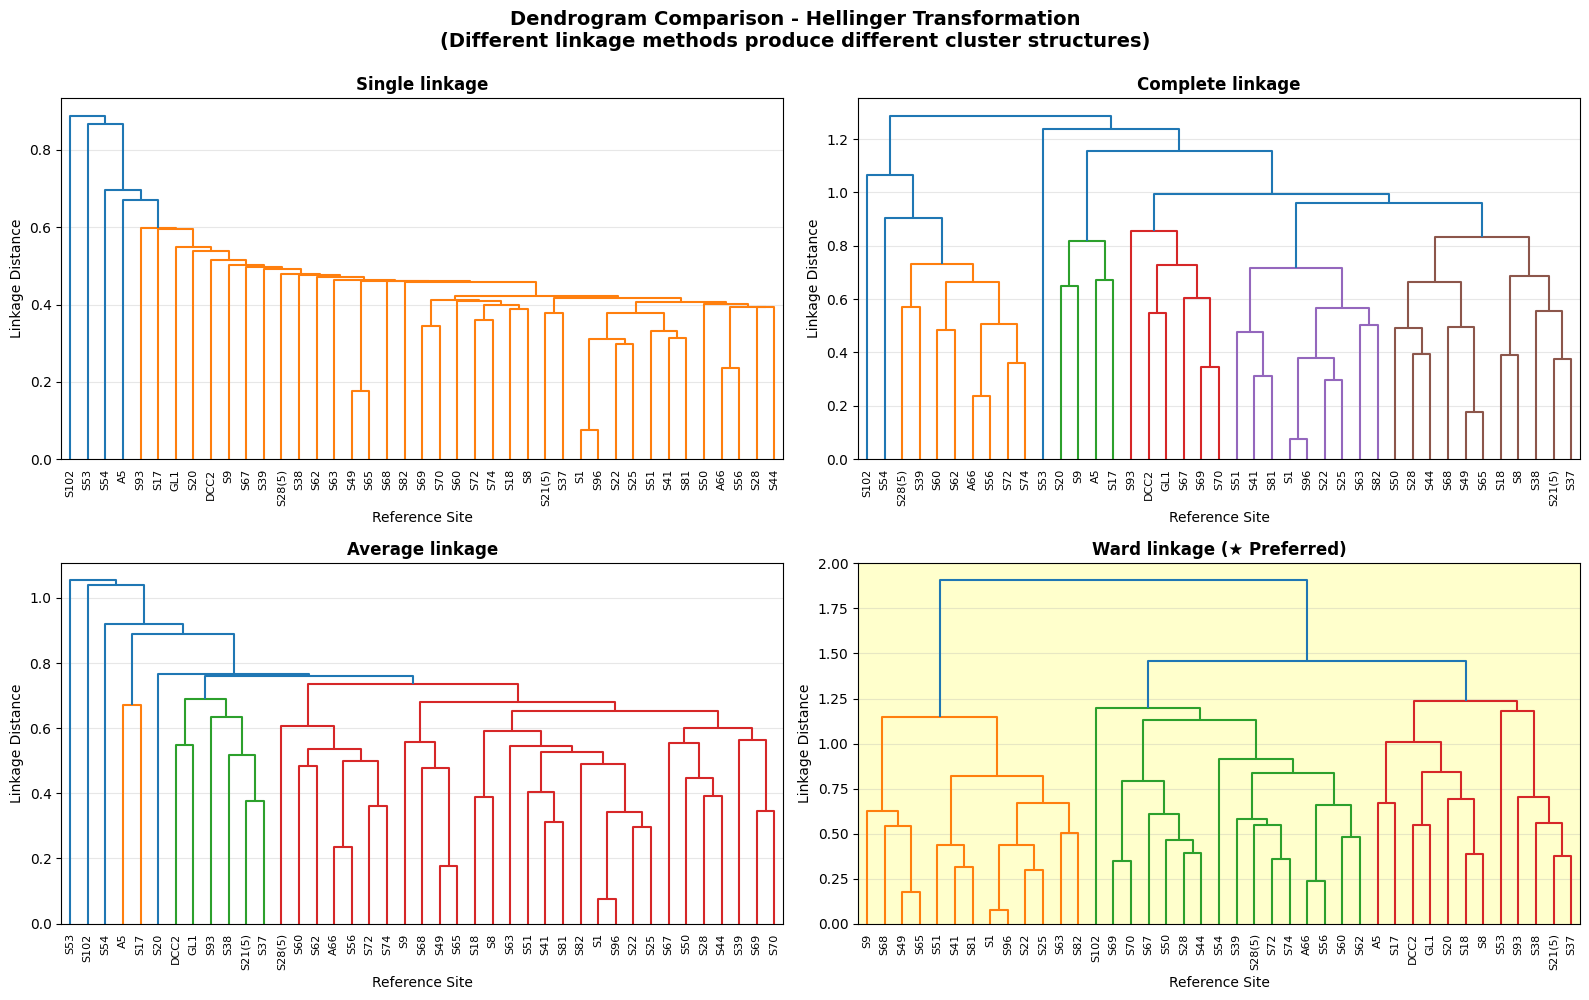

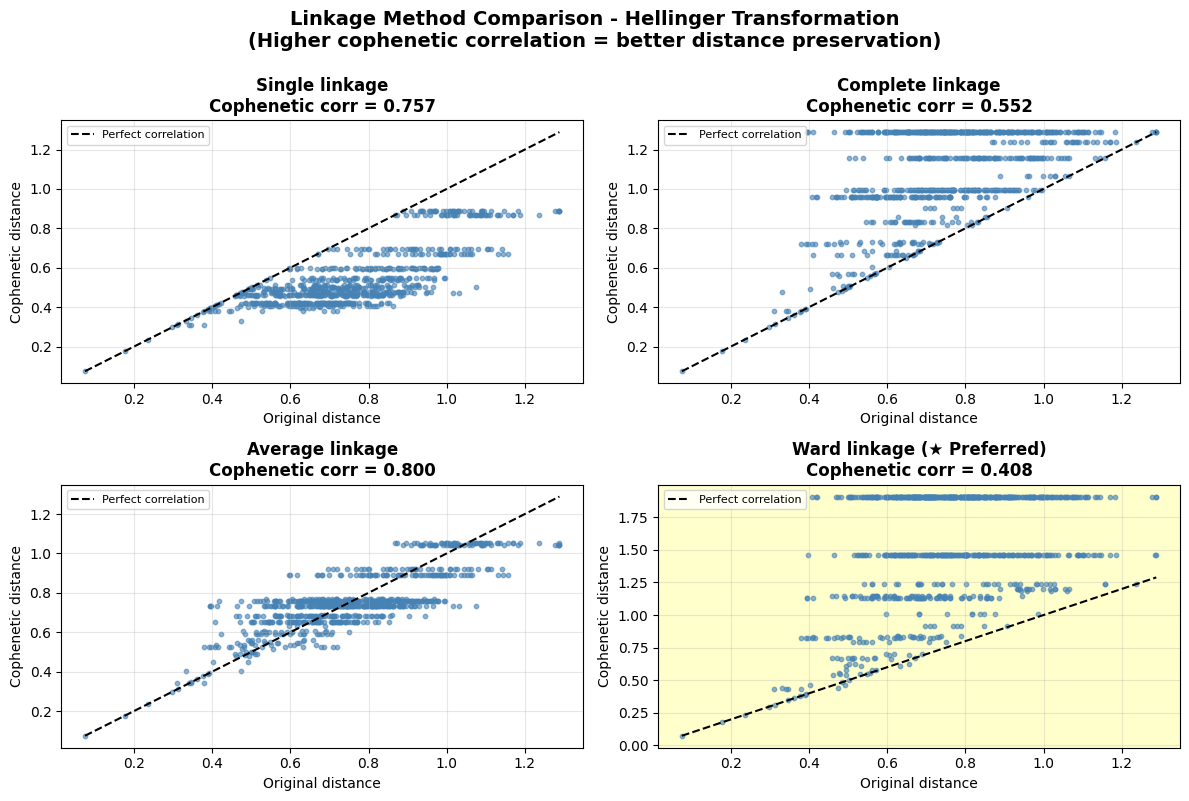

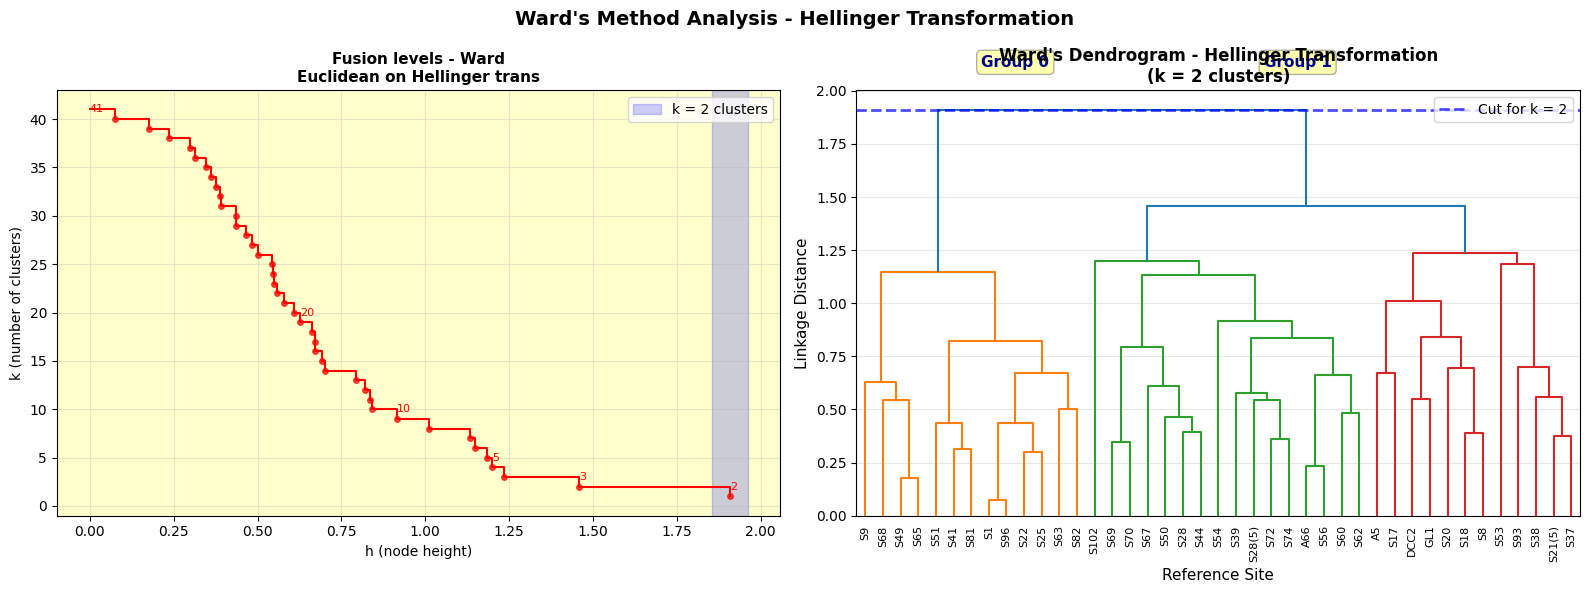

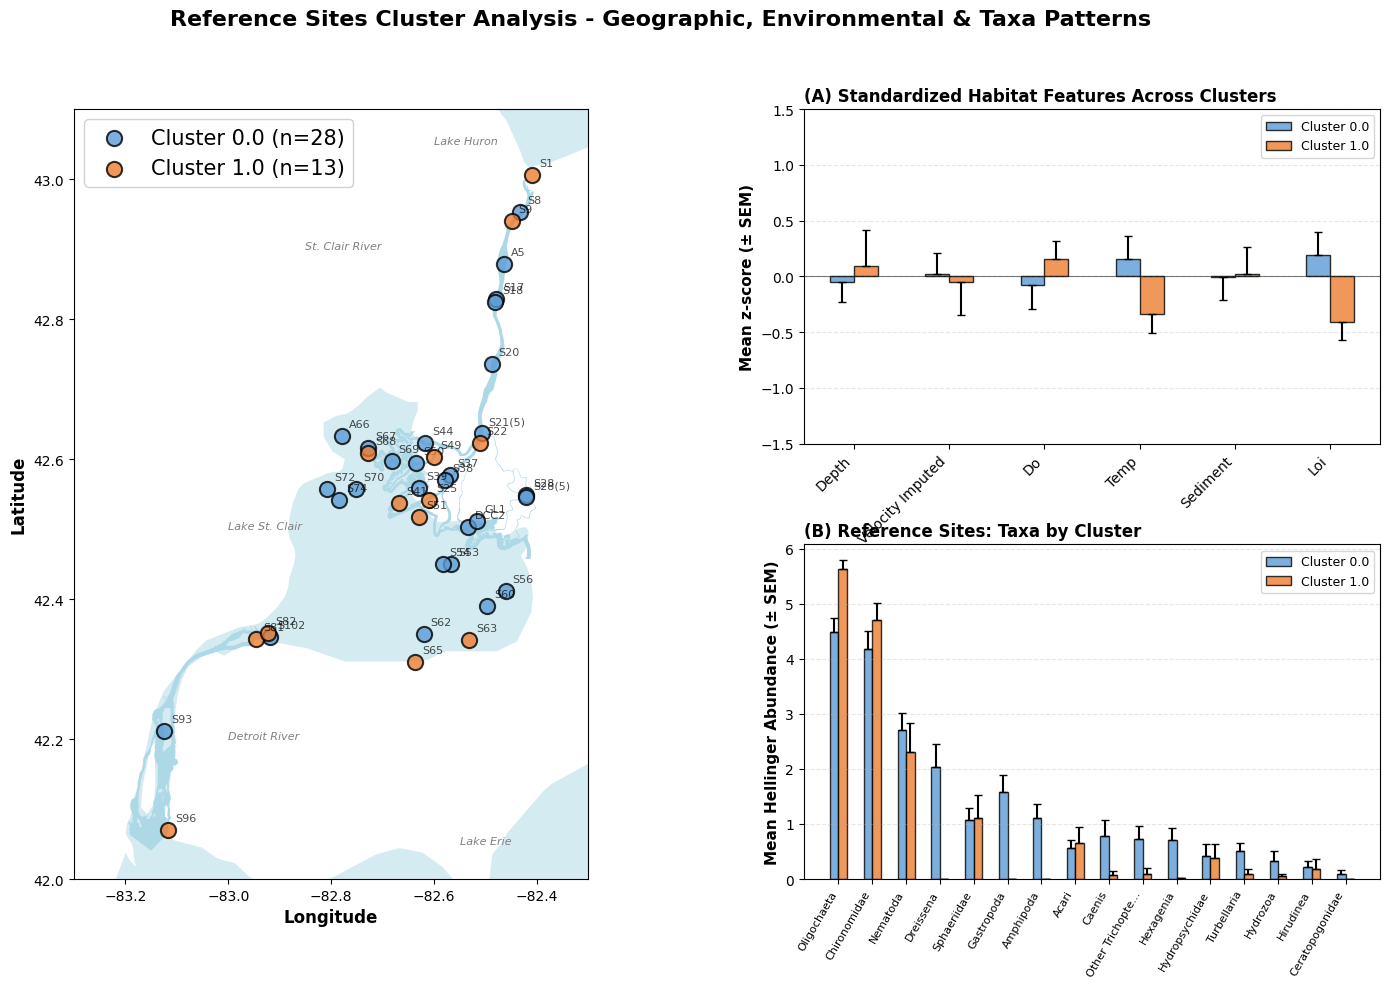

In [286]:
# =============================================================================
# STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES")
print("=" * 80)

# Reload module to pick up changes
import importlib
import sys
modules_to_remove = [key for key in sys.modules.keys() if 'zci.taxa_assemblage_in_refs' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

from zci.taxa_assemblage_in_refs import reference_sites_taxa_assemblage_pipeline

cfg_s2 = KEY_PARAMS['stage2']

# Determine save path
save_path_s2 = FIGURE_PATHS[2] if OUTPUT_PARAMS['save_figures'] else None

stage2_results = reference_sites_taxa_assemblage_pipeline(
    raw_data=raw_data_s1,
    multiindex_data=multiindex_data_s1,
    pollution_column=DATA_PARAMS['pollution_column'],
    # Core parameters
    reference_percentile=cfg_s2['reference_percentile'],
    species_transformation=cfg_s2['species_transformation'],
    n_clusters=cfg_s2['n_clusters'],
    top_n_taxa=cfg_s2['top_n_taxa'],
    env_variables=cfg_s2['env_variables'],
    # Visualization options
    create_cluster_visualization=cfg_s2['create_cluster_visualization'],
    create_dendrogram_comparison=cfg_s2['create_dendrogram_comparison'],
    create_ward_analysis=cfg_s2['create_ward_analysis'],
    create_comparison_plots=cfg_s2['create_comparison_plots'],
    label_positions=cfg_s2['label_positions'],
    # Save path
    save_path=save_path_s2,
    verbose=KEY_PARAMS['verbose'],
)

# Extract outputs
raw_data_s2 = stage2_results['raw_data']
multiindex_data_s2 = stage2_results['multiindex_data']

print(f"\n✓ Stage 2 Complete!")
print(f"  - Reference sites: {(raw_data_s2['if_ref'] == True).sum()}")
print(f"  - Cluster distribution: {stage2_results['cluster_distribution']}")

# Report saved figures
if 'figures' in stage2_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage2_results['figures'])} to {save_path_s2}")

In [287]:
# =============================================================================
# ENVIRONMENTAL AND SPECIES CHARACTERISTICS BY CLUSTER
# =============================================================================
from scipy import stats

print("=" * 80)
print("ENVIRONMENTAL AND SPECIES CHARACTERISTICS BY CLUSTER")
print("=" * 80)

ref_data = raw_data_s2[raw_data_s2['if_ref'] == True]
env_vars = cfg_s2['env_variables']
clusters = sorted(ref_data['clusters'].unique())

def format_pvalue(p):
    """Format p-value with significance stars"""
    if np.isnan(p):
        return "   NA"
    elif p < 0.001:
        return "<0.001***"
    elif p < 0.01:
        return f"{p:.3f}**"
    elif p < 0.05:
        return f"{p:.3f}*"
    elif p < 0.1:
        return f"{p:.3f}."
    else:
        return f"{p:.3f}"

# =============================================================================
# ENVIRONMENTAL CHARACTERISTICS WITH ANOVA
# =============================================================================
print("\n🌿 ENVIRONMENTAL CHARACTERISTICS BY CLUSTER (Reference Sites Only):")
print("-" * 120)

# Create summary table for environmental variables
env_stats = ref_data.groupby('clusters')[env_vars].agg(['mean', 'std', 'count'])

# Compute ANOVA for each environmental variable
env_anova_results = {}
for var in env_vars:
    groups = [ref_data[ref_data['clusters'] == c][var].dropna() for c in clusters]
    if all(len(g) > 1 for g in groups):
        f_stat, p_val = stats.f_oneway(*groups)
        env_anova_results[var] = {'F': f_stat, 'p': p_val}
    else:
        env_anova_results[var] = {'F': np.nan, 'p': np.nan}

# Print header
print(f"\n{'Variable':<35} {'Cluster 0':>16} {'Cluster 1':>16} {'Cluster 2':>16} {'F-stat':>8} {'p-value':>12}")
print("-" * 120)

for var in env_vars:
    var_short = var[:32] + '...' if len(var) > 35 else var
    row = f"{var_short:<35}"
    for cluster in clusters:
        mean_val = env_stats.loc[cluster, (var, 'mean')]
        std_val = env_stats.loc[cluster, (var, 'std')]
        row += f" {mean_val:6.2f} ± {std_val:5.2f}"
    f_val = env_anova_results[var]['F']
    p_val = env_anova_results[var]['p']
    row += f" {f_val:8.2f} {format_pvalue(p_val):>12}"
    print(row)

# Sample sizes per cluster
print("-" * 120)
print(f"{'Sample size (n)':<35}", end="")
for cluster in clusters:
    n = int(env_stats.loc[cluster, (env_vars[0], 'count')])
    print(f" {n:>15}", end="")
print()

# Environment characterization based on cluster means
print("-" * 120)
print(f"{'Environment Type':<35}", end="")

# Characterize each cluster based on key variables
for cluster in clusters:
    depth = env_stats.loc[cluster, ('Measured Depth (m)', 'mean')]
    # velocity = env_stats.loc[cluster, ('Velocity  at bottom (m/sec)_Imputed', 'mean')]
    mps = env_stats.loc[cluster, ('MPS (Phi)', 'mean')]  # Higher phi = finer sediment
    # loi = env_stats.loc[cluster, ('LOI (%)', 'mean')]

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")

# =============================================================================
# SPECIES CHARACTERISTICS WITH ANOVA
# =============================================================================
print("\n\n🐛 TOP TAXA ABUNDANCE BY CLUSTER (Reference Sites Only):")
print("-" * 120)

# Get taxa columns from multiindex_data_s2 (level 0 == 'taxa')
taxa_level_mask = multiindex_data_s2.columns.get_level_values(0) == 'taxa'
taxa_multiindex = multiindex_data_s2.loc[:, taxa_level_mask]
taxa_names = taxa_multiindex.columns.get_level_values(-1).tolist()
species_cols = [c for c in taxa_names if c in raw_data_s2.columns]

if len(species_cols) > 0:
    species_means = ref_data.groupby('clusters')[species_cols].mean()
    
    # Get top 10 taxa by overall abundance in reference sites
    overall_means = ref_data[species_cols].mean().sort_values(ascending=False)
    top_taxa = overall_means.head(10).index.tolist()
    
    # Compute ANOVA for each top taxon
    taxa_anova_results = {}
    for taxon in top_taxa:
        groups = [ref_data[ref_data['clusters'] == c][taxon].dropna() for c in clusters]
        if all(len(g) > 1 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
            taxa_anova_results[taxon] = {'F': f_stat, 'p': p_val}
        else:
            taxa_anova_results[taxon] = {'F': np.nan, 'p': np.nan}
    
    print(f"\n{'Taxon':<30} {'Cluster 0':>13} {'Cluster 1':>13} {'Cluster 2':>13} {'F-stat':>8} {'p-value':>12}")
    print("-" * 120)
    
    for taxon in top_taxa:
        taxon_short = str(taxon)[:27] + '...' if len(str(taxon)) > 30 else str(taxon)
        row = f"{taxon_short:<30}"
        for cluster in clusters:
            val = species_means.loc[cluster, taxon]
            row += f" {val:>13.3f}"
        f_val = taxa_anova_results[taxon]['F']
        p_val = taxa_anova_results[taxon]['p']
        row += f" {f_val:8.2f} {format_pvalue(p_val):>12}"
        print(row)
    
    print(f"\n(Showing top 10 of {len(species_cols)} total taxa)")
    print("Significance: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")
else:
    print("Species columns not found.")

print("\n" + "=" * 80)

ENVIRONMENTAL AND SPECIES CHARACTERISTICS BY CLUSTER

🌿 ENVIRONMENTAL CHARACTERISTICS BY CLUSTER (Reference Sites Only):
------------------------------------------------------------------------------------------------------------------------

Variable                                   Cluster 0        Cluster 1        Cluster 2   F-stat      p-value
------------------------------------------------------------------------------------------------------------------------
Measured Depth (m)                    3.11 ±  2.22   3.45 ±  2.66     0.18        0.675
Velocity  at bottom (m/sec)_Imputed   0.10 ±  0.09   0.09 ±  0.10     0.05        0.832
Water DO Bottom (mg/L)                9.44 ±  0.94   9.63 ±  0.47     0.46        0.501
Temperature (oC)                     20.94 ±  2.15  20.00 ±  1.15     2.22        0.144
MPS (Phi)                             1.26 ±  0.92   1.28 ±  0.78     0.01        0.939
LOI (%)                               1.73 ±  1.21   1.07 ±  0.62     3.43       0.071.

---

## Stage 3: Environment-Driven Taxa Clusters (RDA + LDA)

**Objective**: Validate that clusters correspond to distinct environmental conditions and predict clusters for non-reference sites.

**Key Parameters**:
- `rda_n_permutations`: Number of permutations for RDA significance testing
- `env_variables`: Habitat variables used for RDA and LDA
- `lda_n_iterations`: Monte Carlo cross-validation iterations for LDA


STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)

ENVIRONMENT-DRIVEN TAXA CLUSTERS ANALYSIS PIPELINE

This pipeline performs:
  1. RDA ordination analysis
  2. LDA classification with Monte Carlo CV
  3. LDA-RDA axis comparison
  4. Non-reference site prediction
  5. Data integration with complete cluster labels


STEP 1: REDUNDANCY ANALYSIS (RDA)

REDUNDANCY ANALYSIS (RDA) PIPELINE

Analyzing habitat-taxa relationships at reference sites

Step 1: Filtering reference sites...
  - Total sites: 41
  - Reference sites: 41
  - Clusters: 2

Step 2: Preparing environmental data...
  - Standardizing environmental variables (z-score)
  - Environmental variables: 6
  - Shape: (41, 6)

Step 3: Preparing taxa data...
  - Taxa transformation: Hellinger
  - Number of taxa: 16
  - Shape: (41, 16)

Step 4: Fitting RDA model...
  ✓ RDA model fitted successfully
  - R²: 0.1989
  - Adjusted R²: 0.0575
  - Constrained inertia: 2.3836
  - Residual inertia: 9.6026

Step 5: Performing permutation test

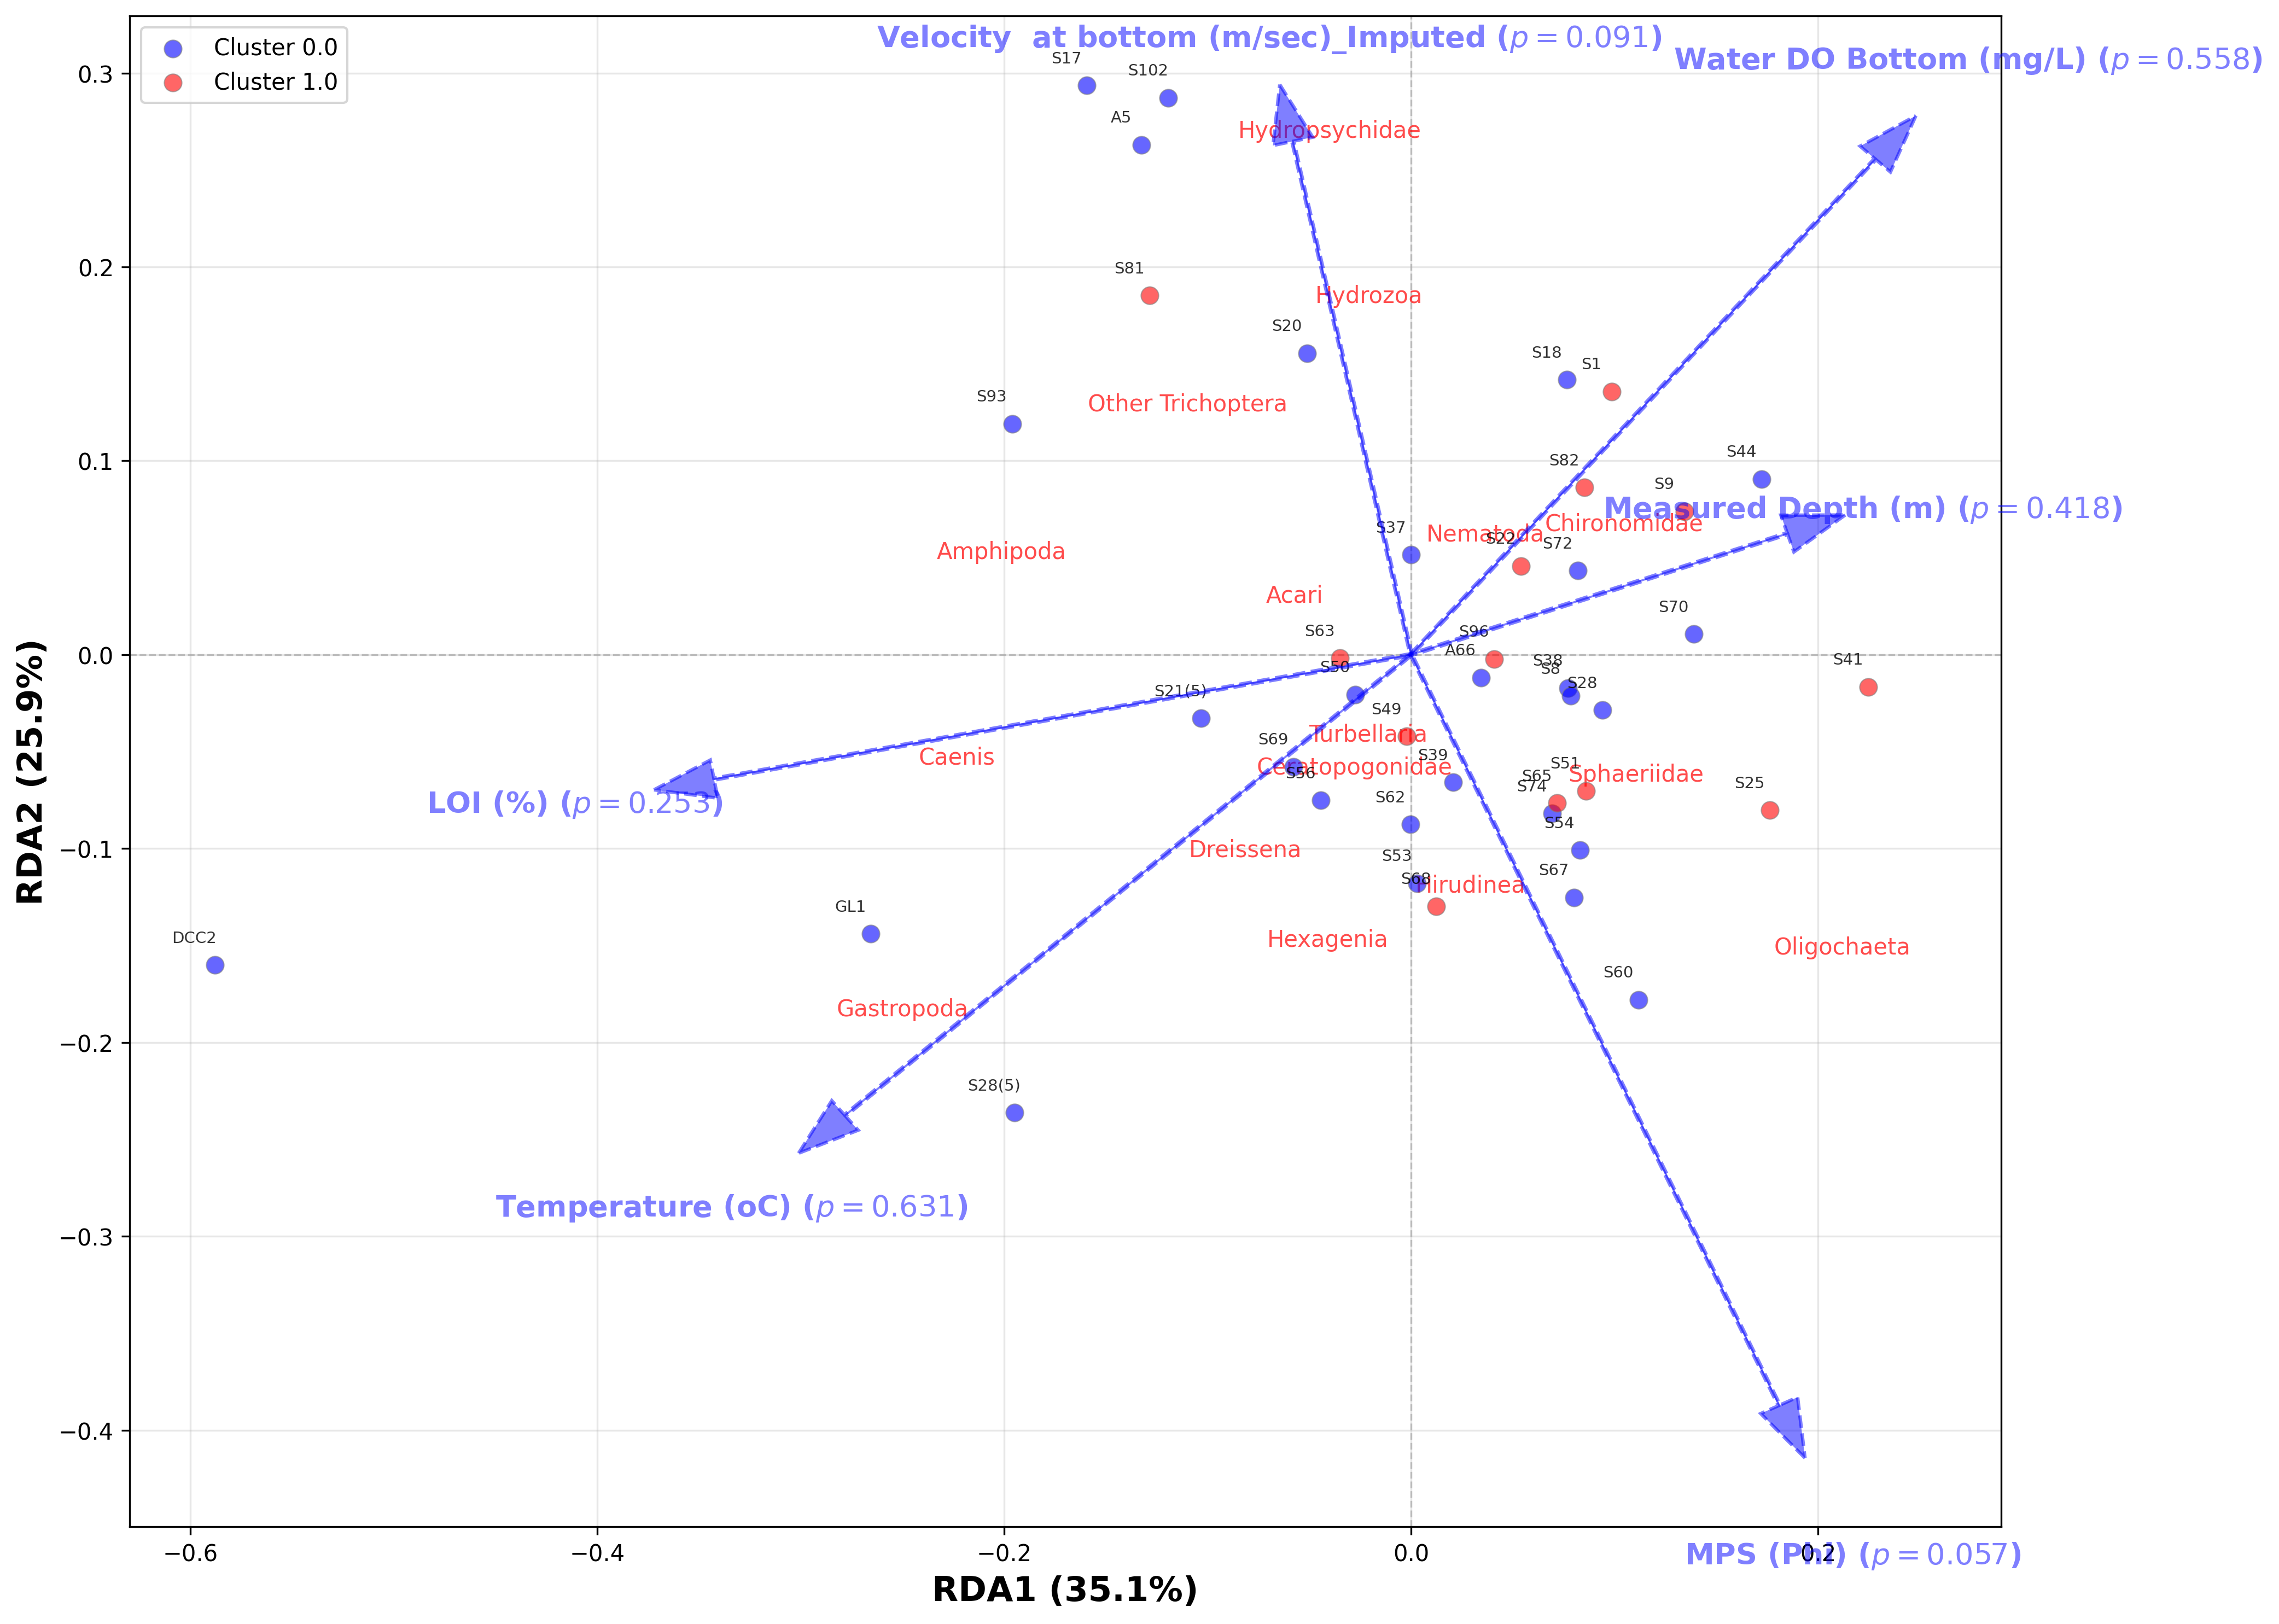

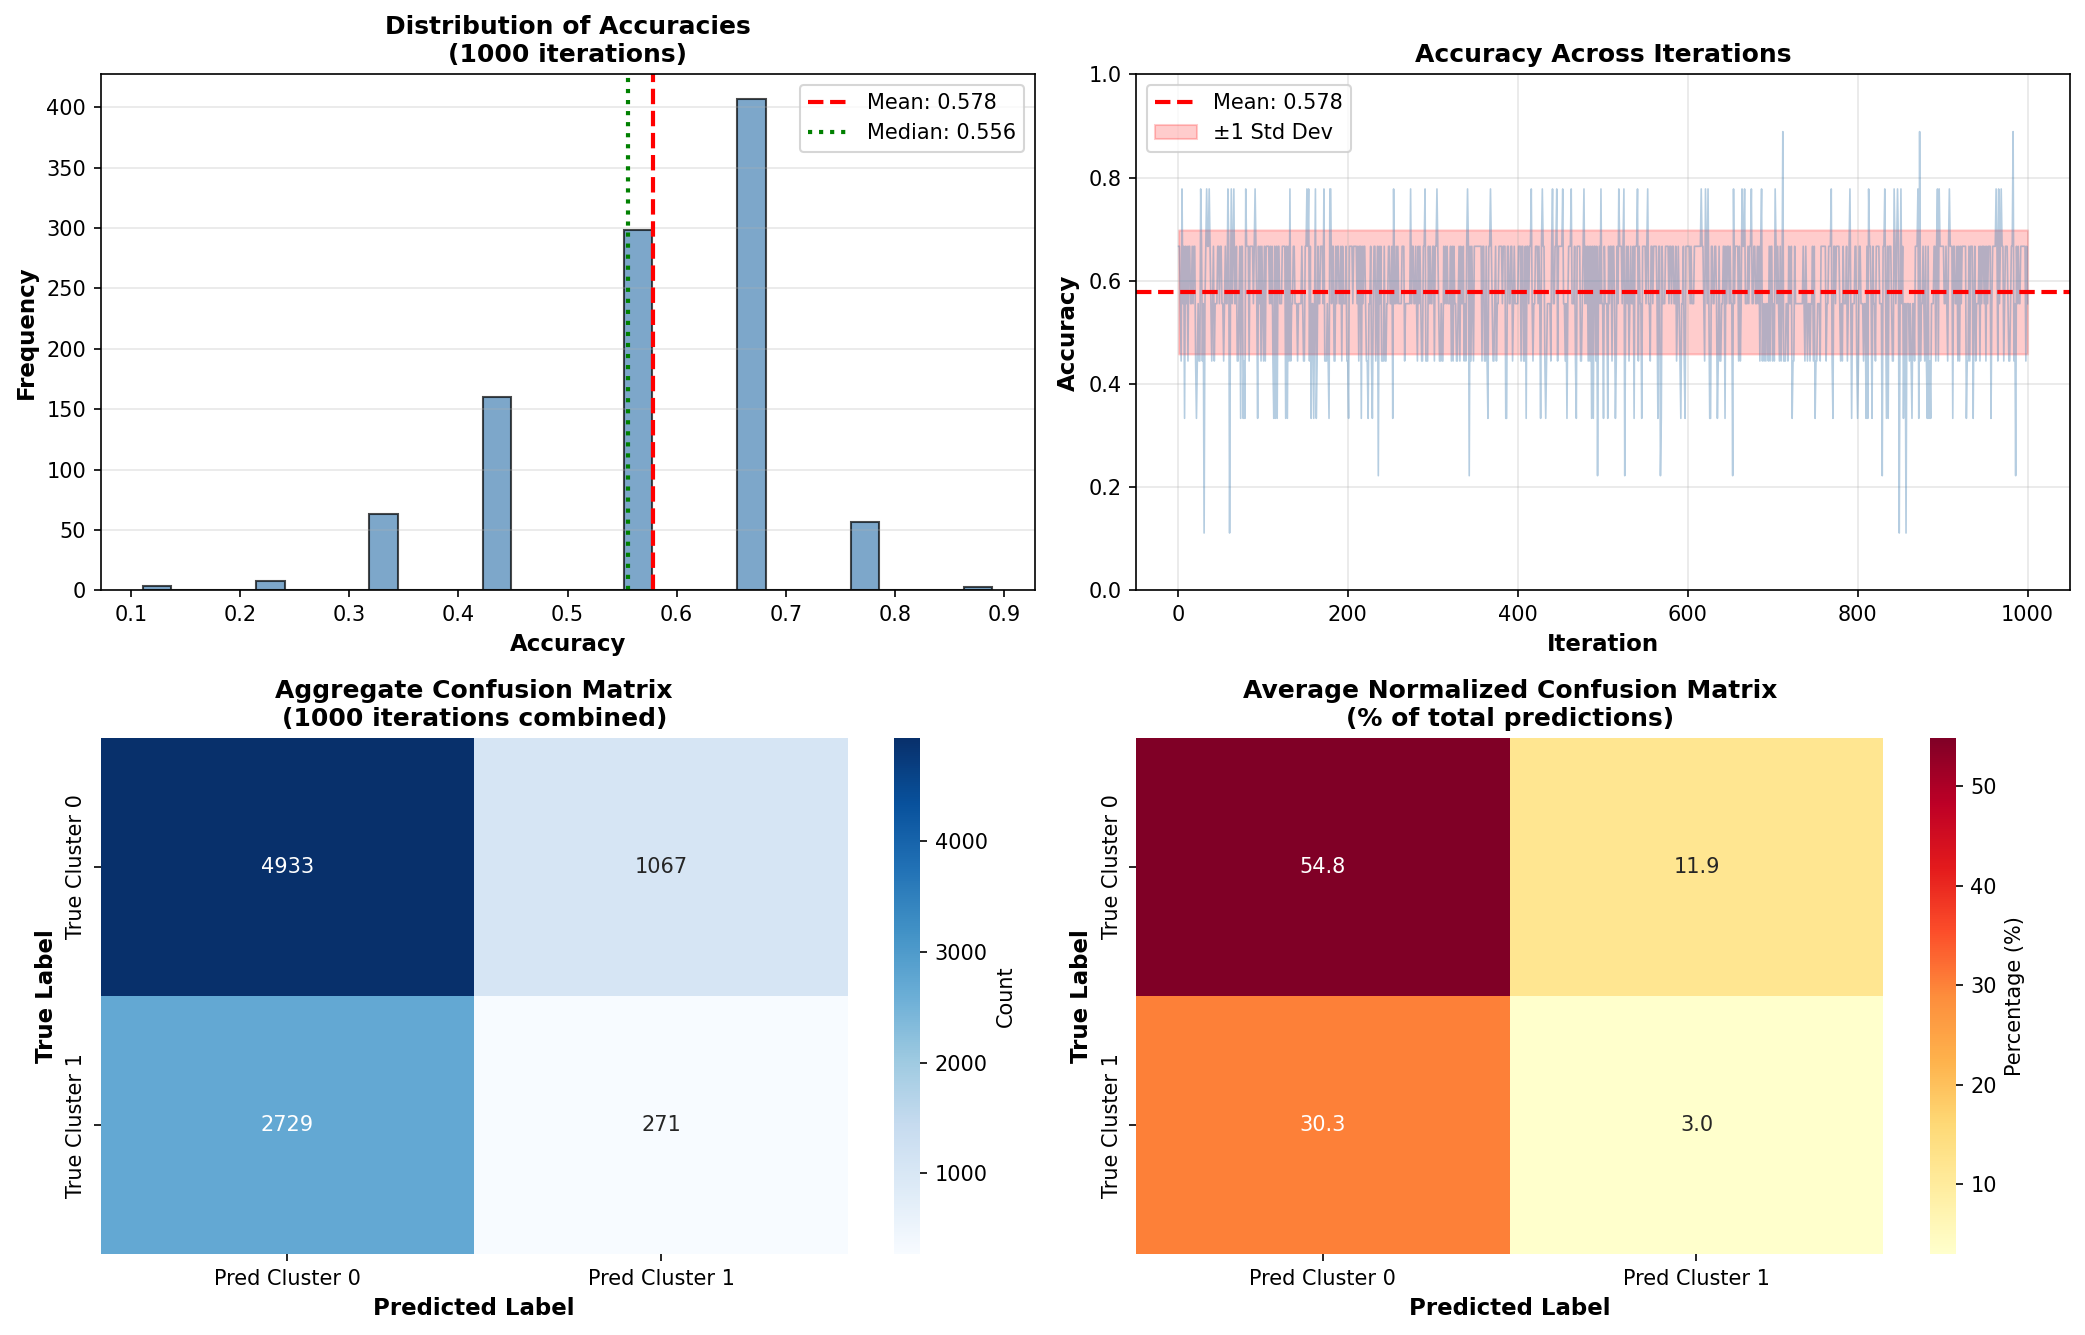

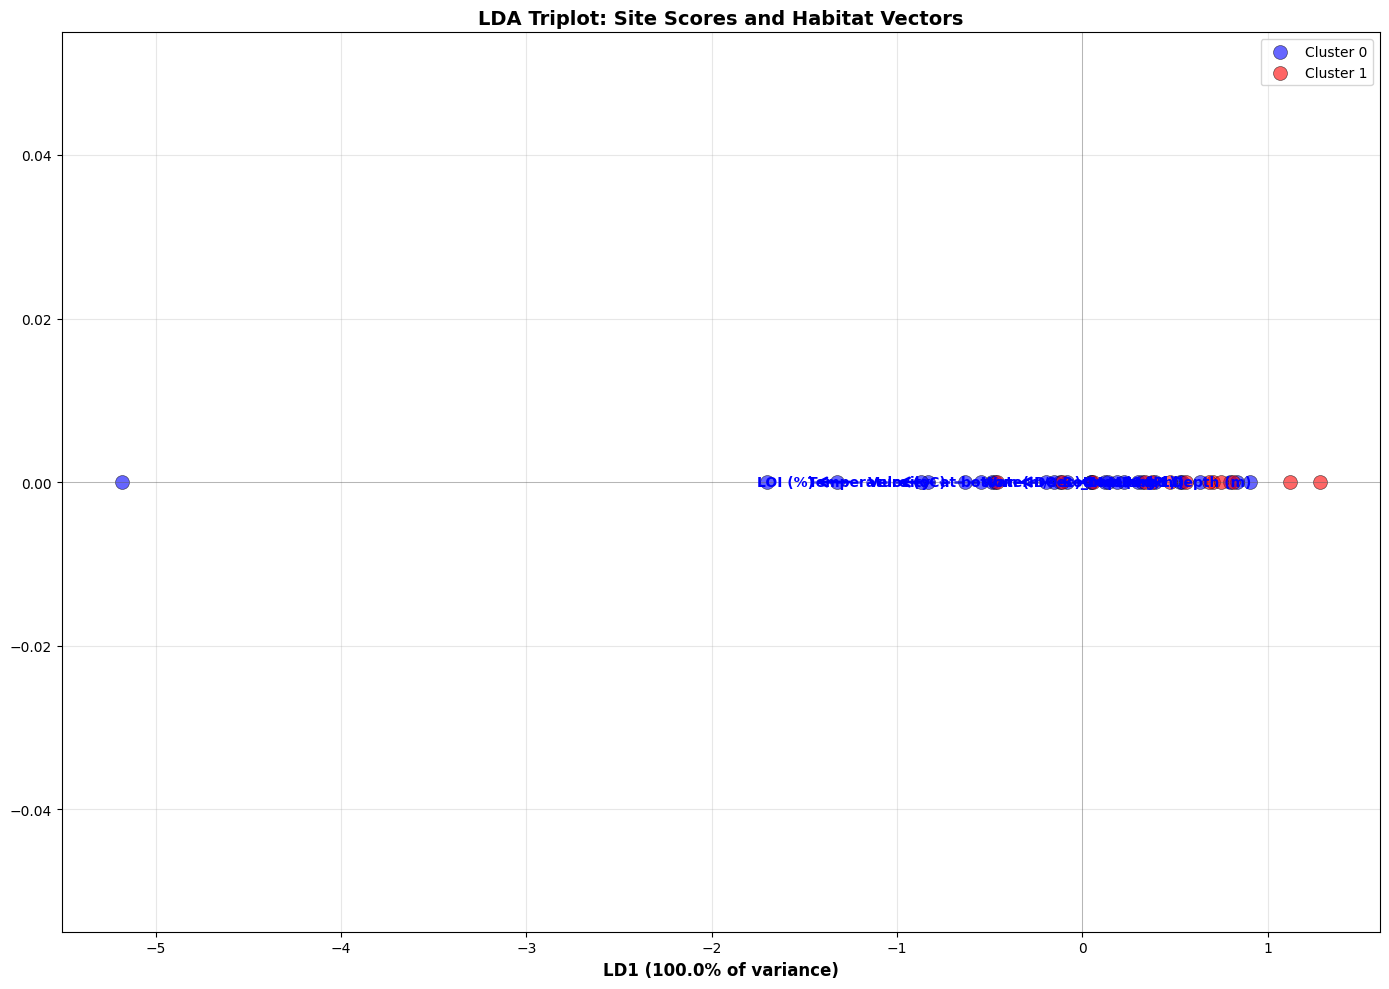

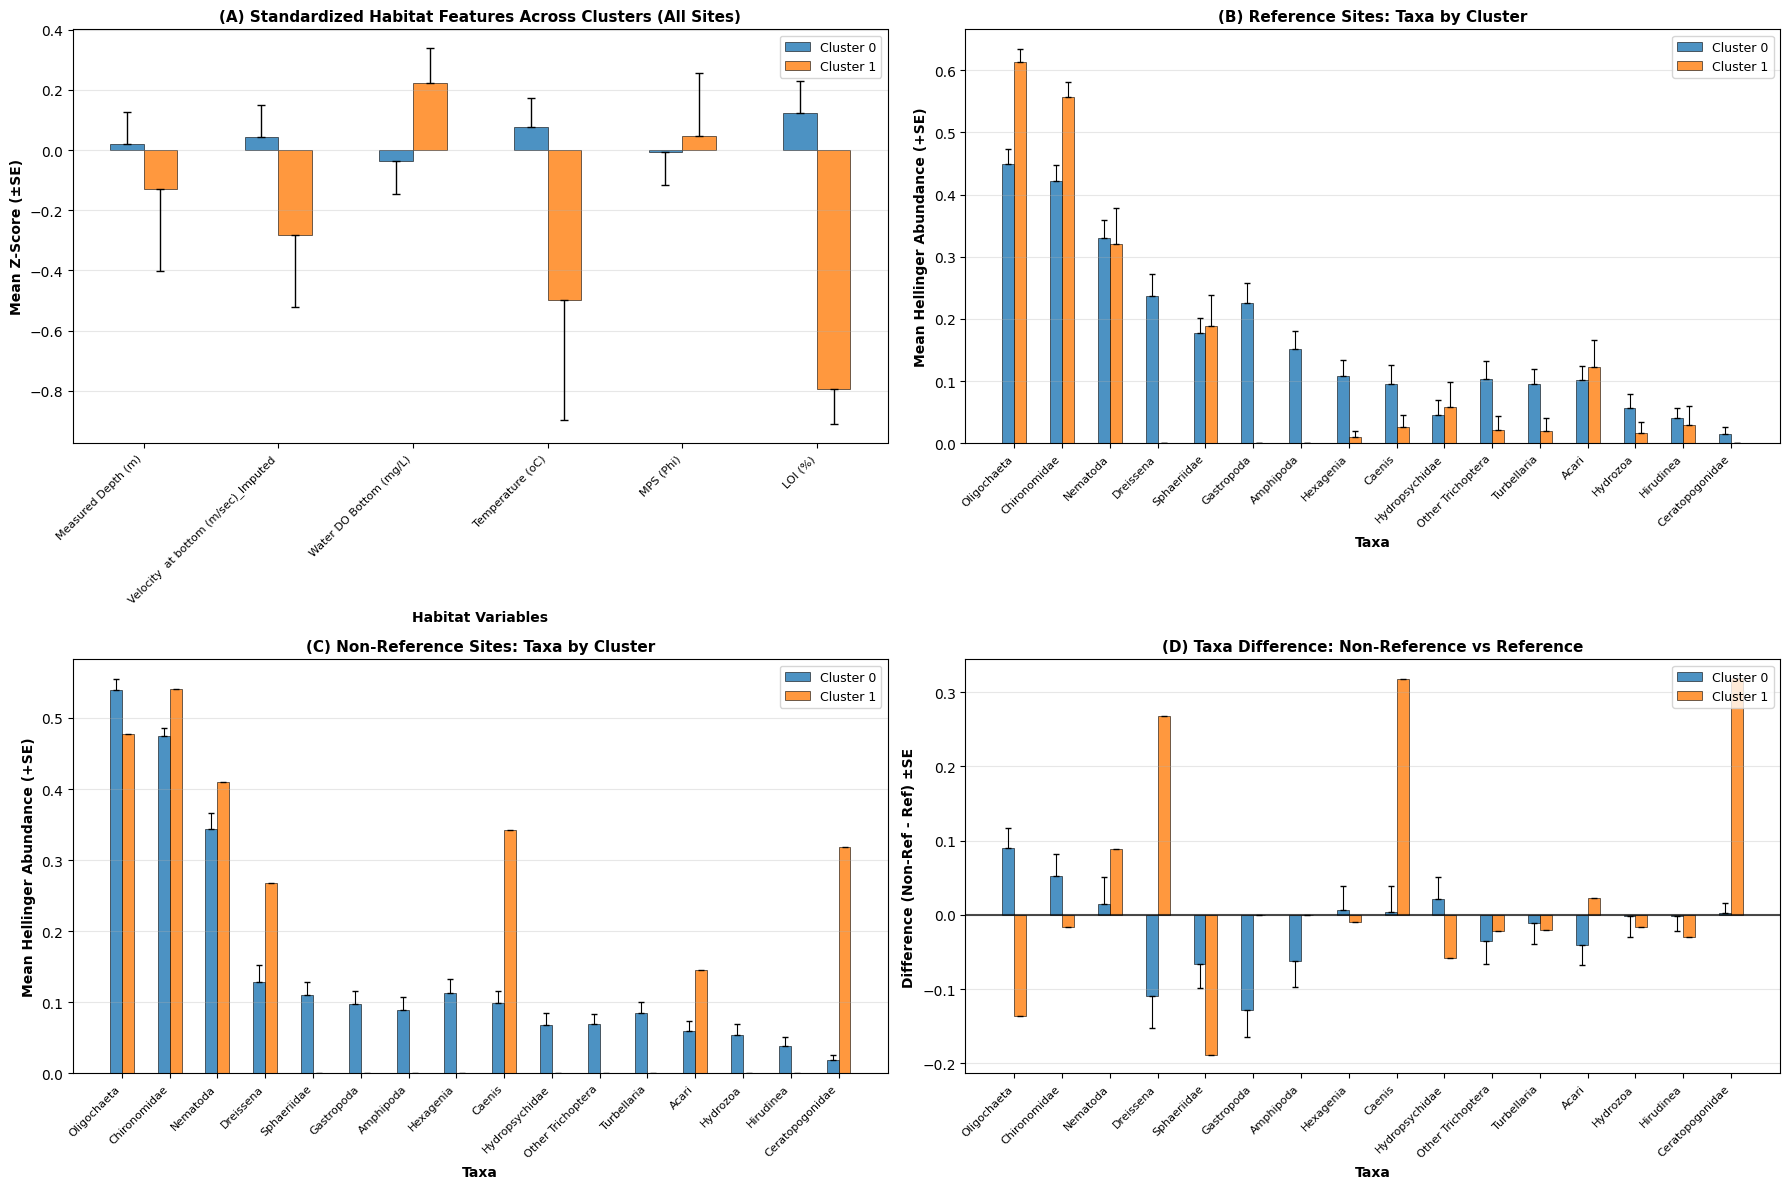

In [288]:
# =============================================================================
# STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)")
print("=" * 80)

from zci.env_driven_taxa_clusters import perform_env_taxa_analysis

cfg_s2 = KEY_PARAMS['stage2']
cfg_s3 = KEY_PARAMS['stage3']

# Determine save path
save_path_s3 = FIGURE_PATHS[3] if OUTPUT_PARAMS['save_figures'] else None

stage3_results = perform_env_taxa_analysis(
    raw_data=raw_data_s2,
    multiindex_data=multiindex_data_s2,
    env_variables=cfg_s2['env_variables'],          # Use same env variables from Stage 2
    cluster_column=DATA_PARAMS['cluster_column'],
    ref_column=DATA_PARAMS['ref_column'],
    # RDA parameters
    rda_log_transform_env=cfg_s3['rda_log_transform_env'],
    rda_standardize_env=cfg_s3['rda_standardize_env'],
    taxa_transformation=cfg_s3['taxa_transformation'],
    top_n_taxa=cfg_s3['top_n_taxa_rda'],
    rda_n_permutations=cfg_s3['rda_n_permutations'],
    # LDA parameters
    lda_log_transform_env=cfg_s3['lda_log_transform_env'],
    lda_standardize_env=cfg_s3['lda_standardize_env'],
    lda_n_iterations=cfg_s3['lda_n_iterations'],
    lda_test_size=cfg_s3['lda_test_size'],
    # Visualization parameters
    rda_arrow_scale=cfg_s3['rda_arrow_scale'],
    rda_species_scale=cfg_s3['rda_species_scale'],
    rda_figsize=cfg_s3['rda_figsize'],
    lda_cv_figsize=cfg_s3['lda_cv_figsize'],
    lda_arrow_scale=cfg_s3['lda_arrow_scale'],
    # Control
    random_state=cfg_s3['random_state'],
    save_path=save_path_s3,
    verbose=KEY_PARAMS['verbose'],
)

# Extract outputs (clusters now assigned to all sites)
raw_data_s3 = stage3_results['updated_raw_data']
multiindex_data_s3 = stage3_results['updated_multiindex_data']

print(f"\n✓ Stage 3 Complete!")
print(f"  - RDA R²: {stage3_results['rda_results']['rda_model'].fit_.r2:.3f}")
print(f"  - RDA Global Test p-value: {stage3_results['rda_results']['global_test'].p_value:.4f}")
print(f"  - LDA Full Model Accuracy: {stage3_results['lda_results']['accuracy']:.2%}")
print(f"  - LDA CV Mean Accuracy: {stage3_results['lda_cv_results']['mean_accuracy']:.2%} ± {stage3_results['lda_cv_results']['std_accuracy']:.2%}")

# Report saved figures
if 'figures' in stage3_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage3_results['figures'])} to {save_path_s3}")

In [289]:
print(f"  - RDA R²: {stage3_results['rda_results']['rda_model'].fit_.r2:.3f}")

  - RDA R²: 0.199


# Test module reload
import importlib
import sys

# Remove cached modules
modules_to_remove = [key for key in sys.modules.keys() if 'zci.community_composition_measures' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

# Now reimport
from zci.community_composition_measures.pipeline import community_composition_pipeline
print("✓ Reloaded community_composition_pipeline module")
print("✓ Pipeline is ready with all 5 blocks (PCA, ZCI, Regression, Visualization, DataUpdating)")

In [290]:
# Reload module to pick up changes
import importlib
import sys

# Remove cached modules
modules_to_remove = [key for key in sys.modules.keys() if 'zci' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

# Now reimport
from zci.community_composition_measures import community_composition_pipeline
print("✓ Reloaded community_composition_pipeline module")
print(f"  - Function signature has 'create_pollution_vs_species_pc_plot': {'create_pollution_vs_species_pc_plot' in community_composition_pipeline.__code__.co_varnames}")

✓ Reloaded community_composition_pipeline module
  - Function signature has 'create_pollution_vs_species_pc_plot': True



STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)
COMMUNITY COMPOSITION ANALYSIS PIPELINE

Configuration:
  Taxa transformation: hellinger
  Training percentile: 100.0%
  Variance threshold: 70%
  ZCI method: least_pollution_threshold

BLOCK 1: PCA ANALYSIS
Taxa transformation: hellinger
Training percentile: 100.0%
Variance threshold: 70%

--- Extracting taxa data ---
Taxa data shape: (104, 16)

--- Selecting training sites ---
Using all sites for PCA training (percentile=100)

--- Fitting PCA models ---
FITTING PCA MODELS FOR EACH CLUSTER
Taxa transformation: hellinger
Variance threshold: 70%
Number of clusters: 2

--- Cluster 0 ---
  Training sites: 90
  Number of species: 16
  Number of PCs: 7
  Variance explained:
    PC1: 23.76%
    PC2: 13.18%
    PC3: 10.16%
  Total variance: 74.90%

--- Cluster 1 ---
  Training sites: 14
  Number of species: 16
  Number of PCs: 3
  Variance explained:
    PC1: 36.65%
    PC2: 20.26%
    PC3: 13.44%
  Total variance: 70.35%

BLOCK 2: ZC

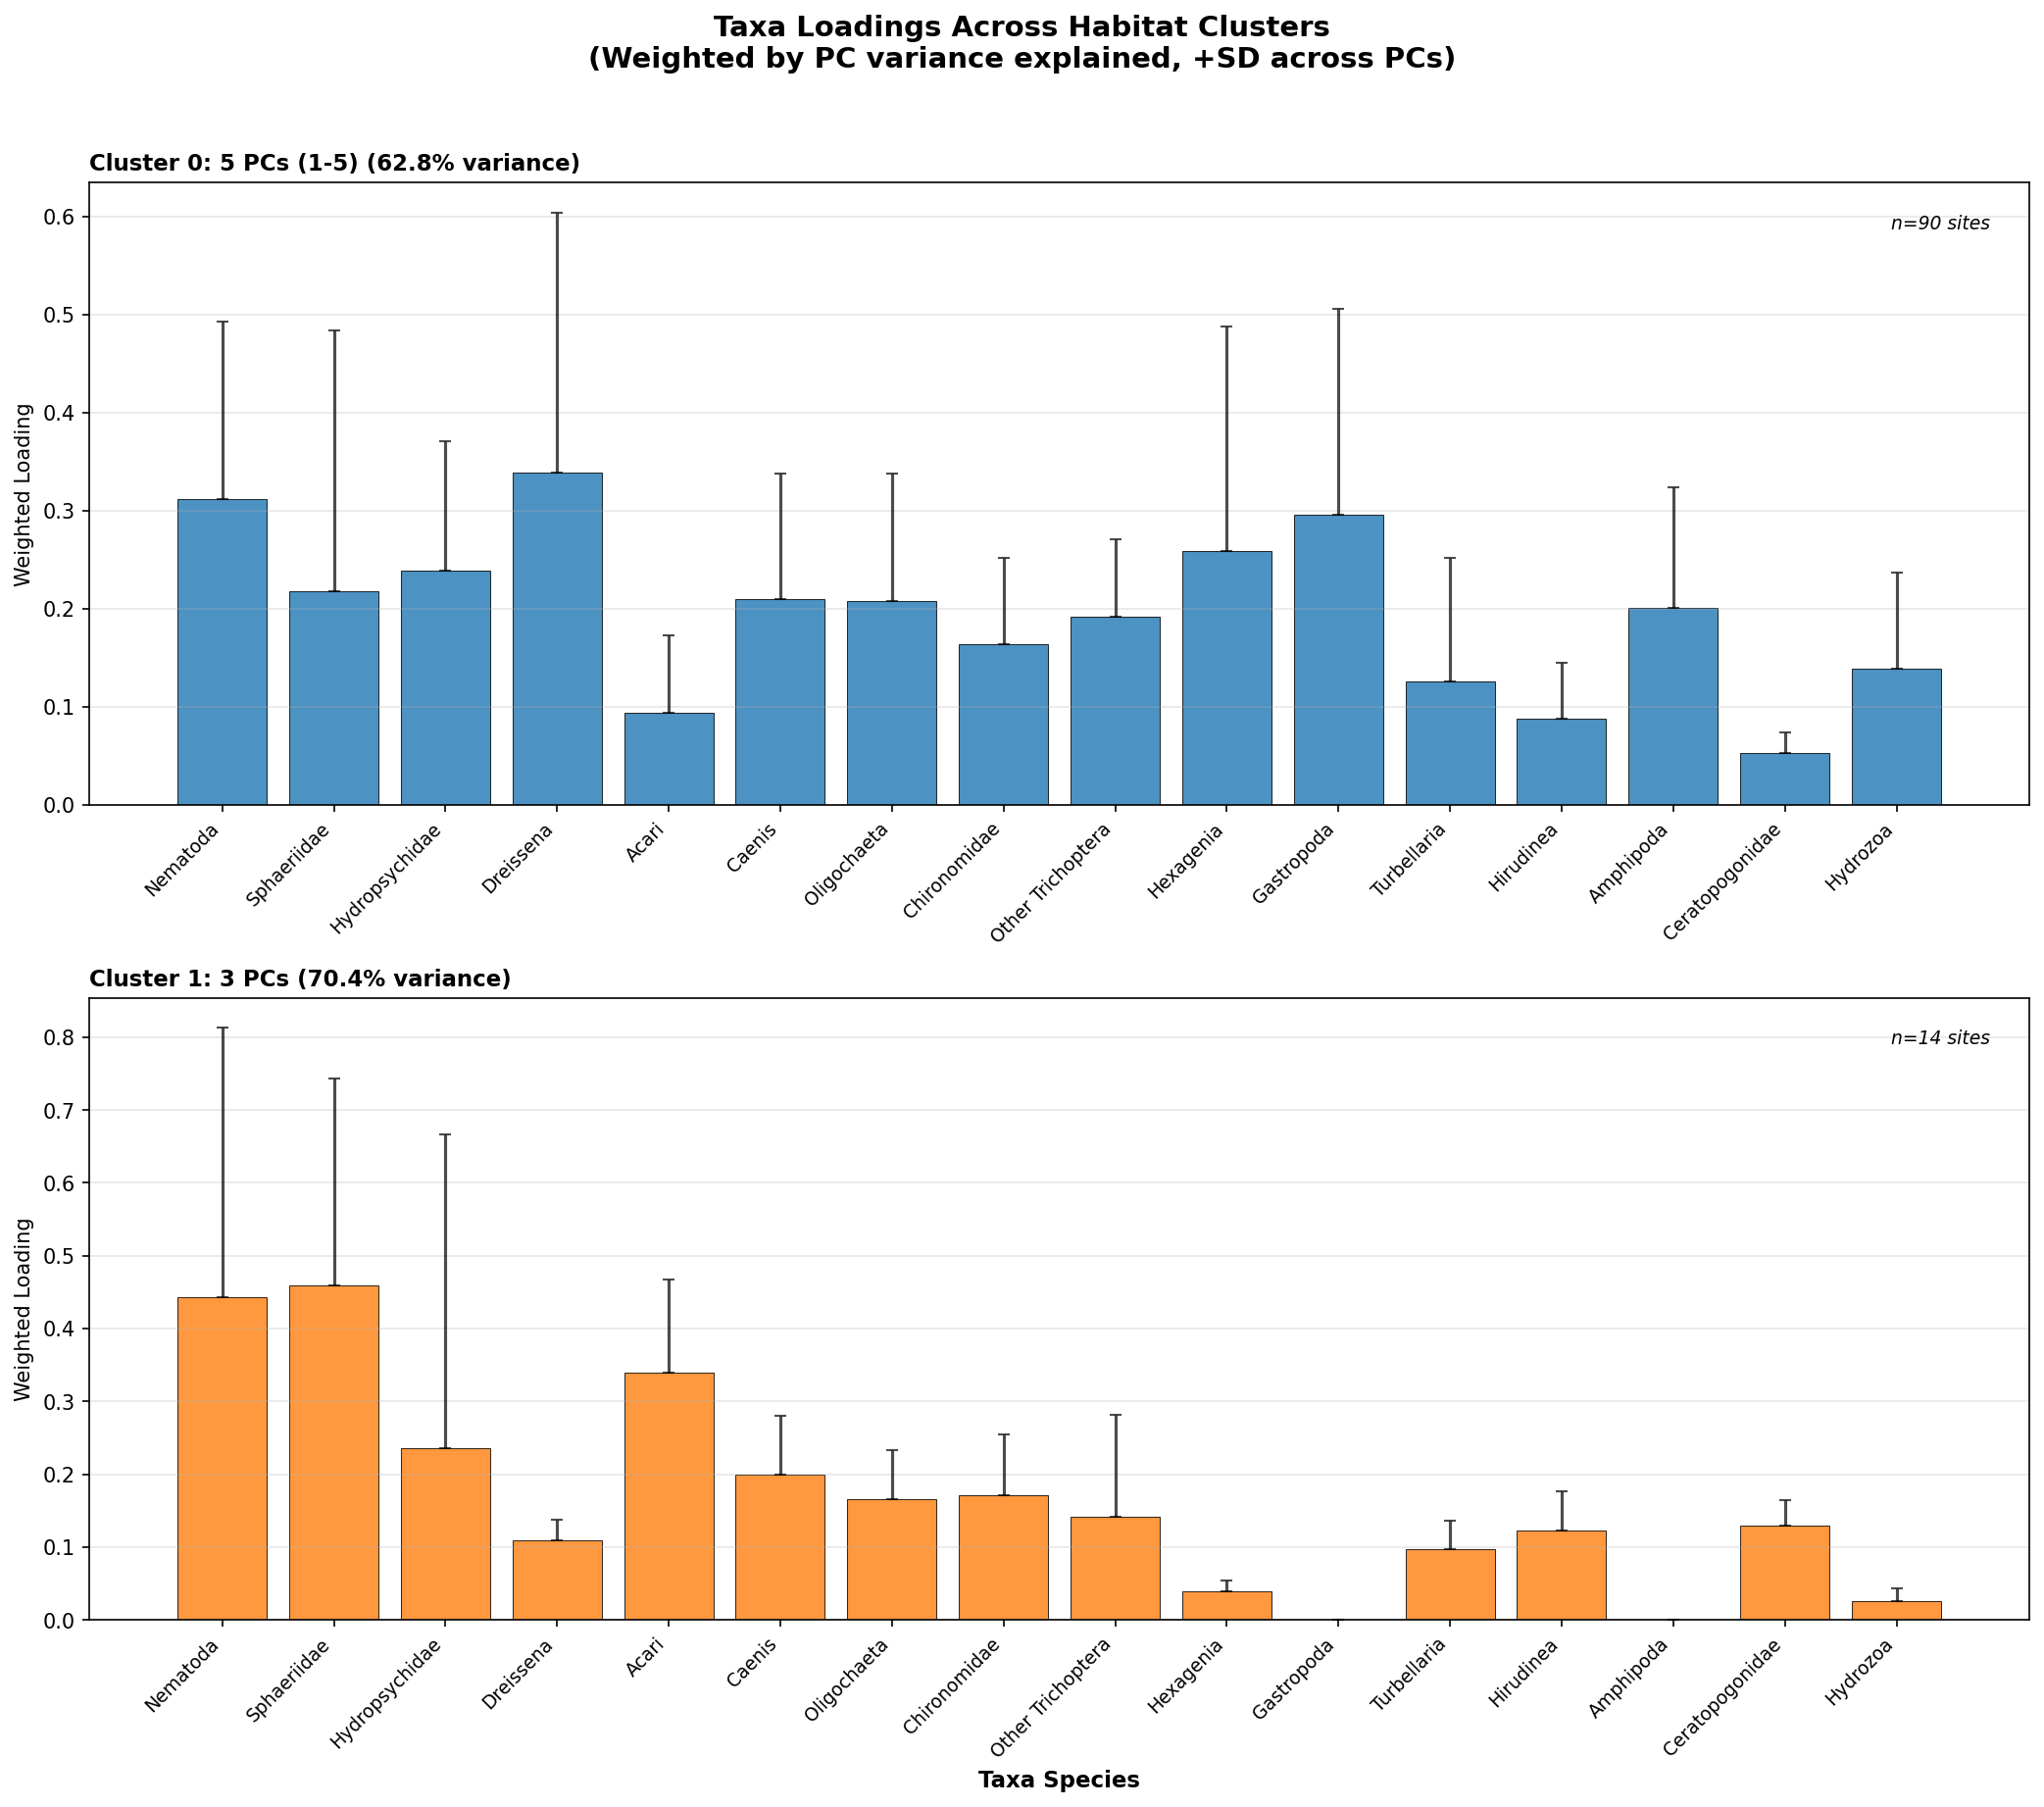

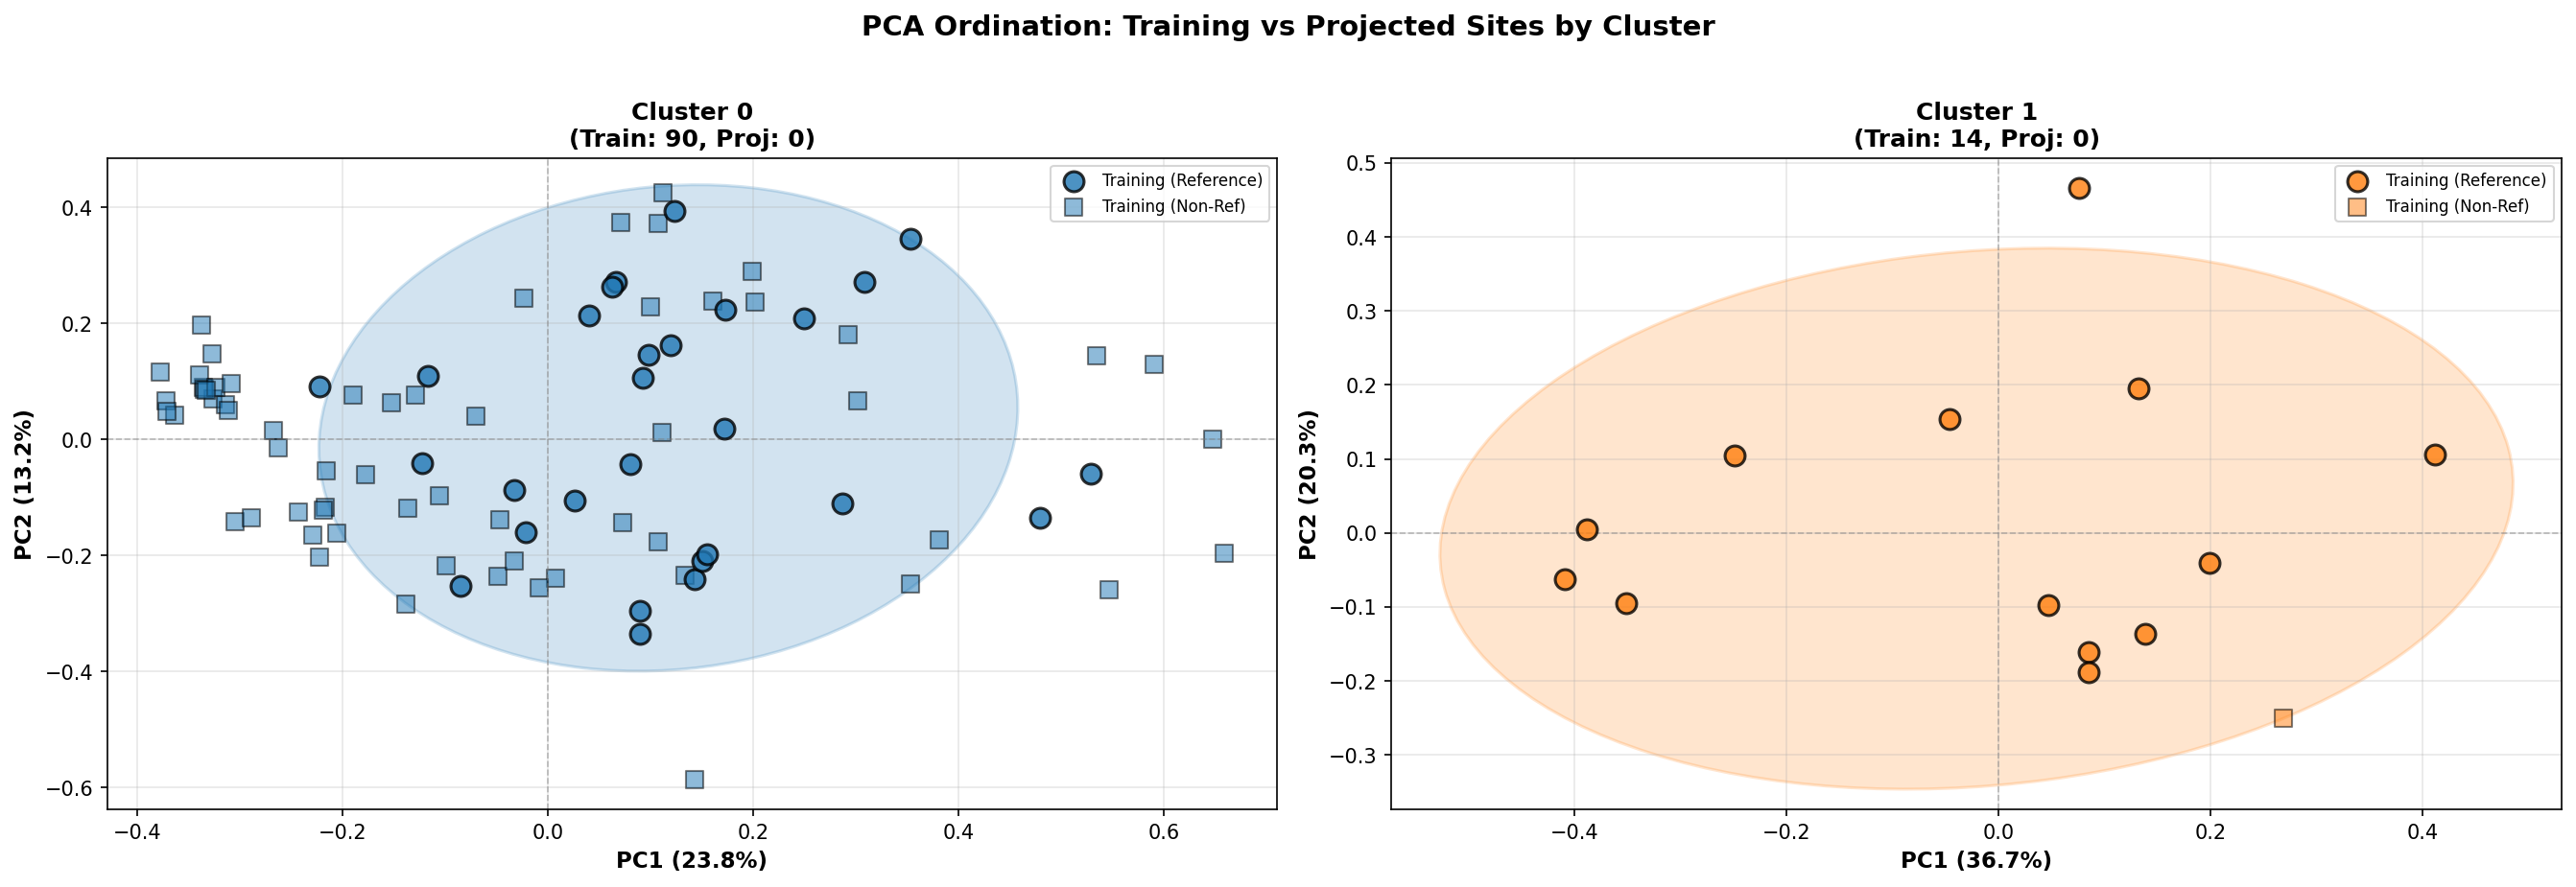

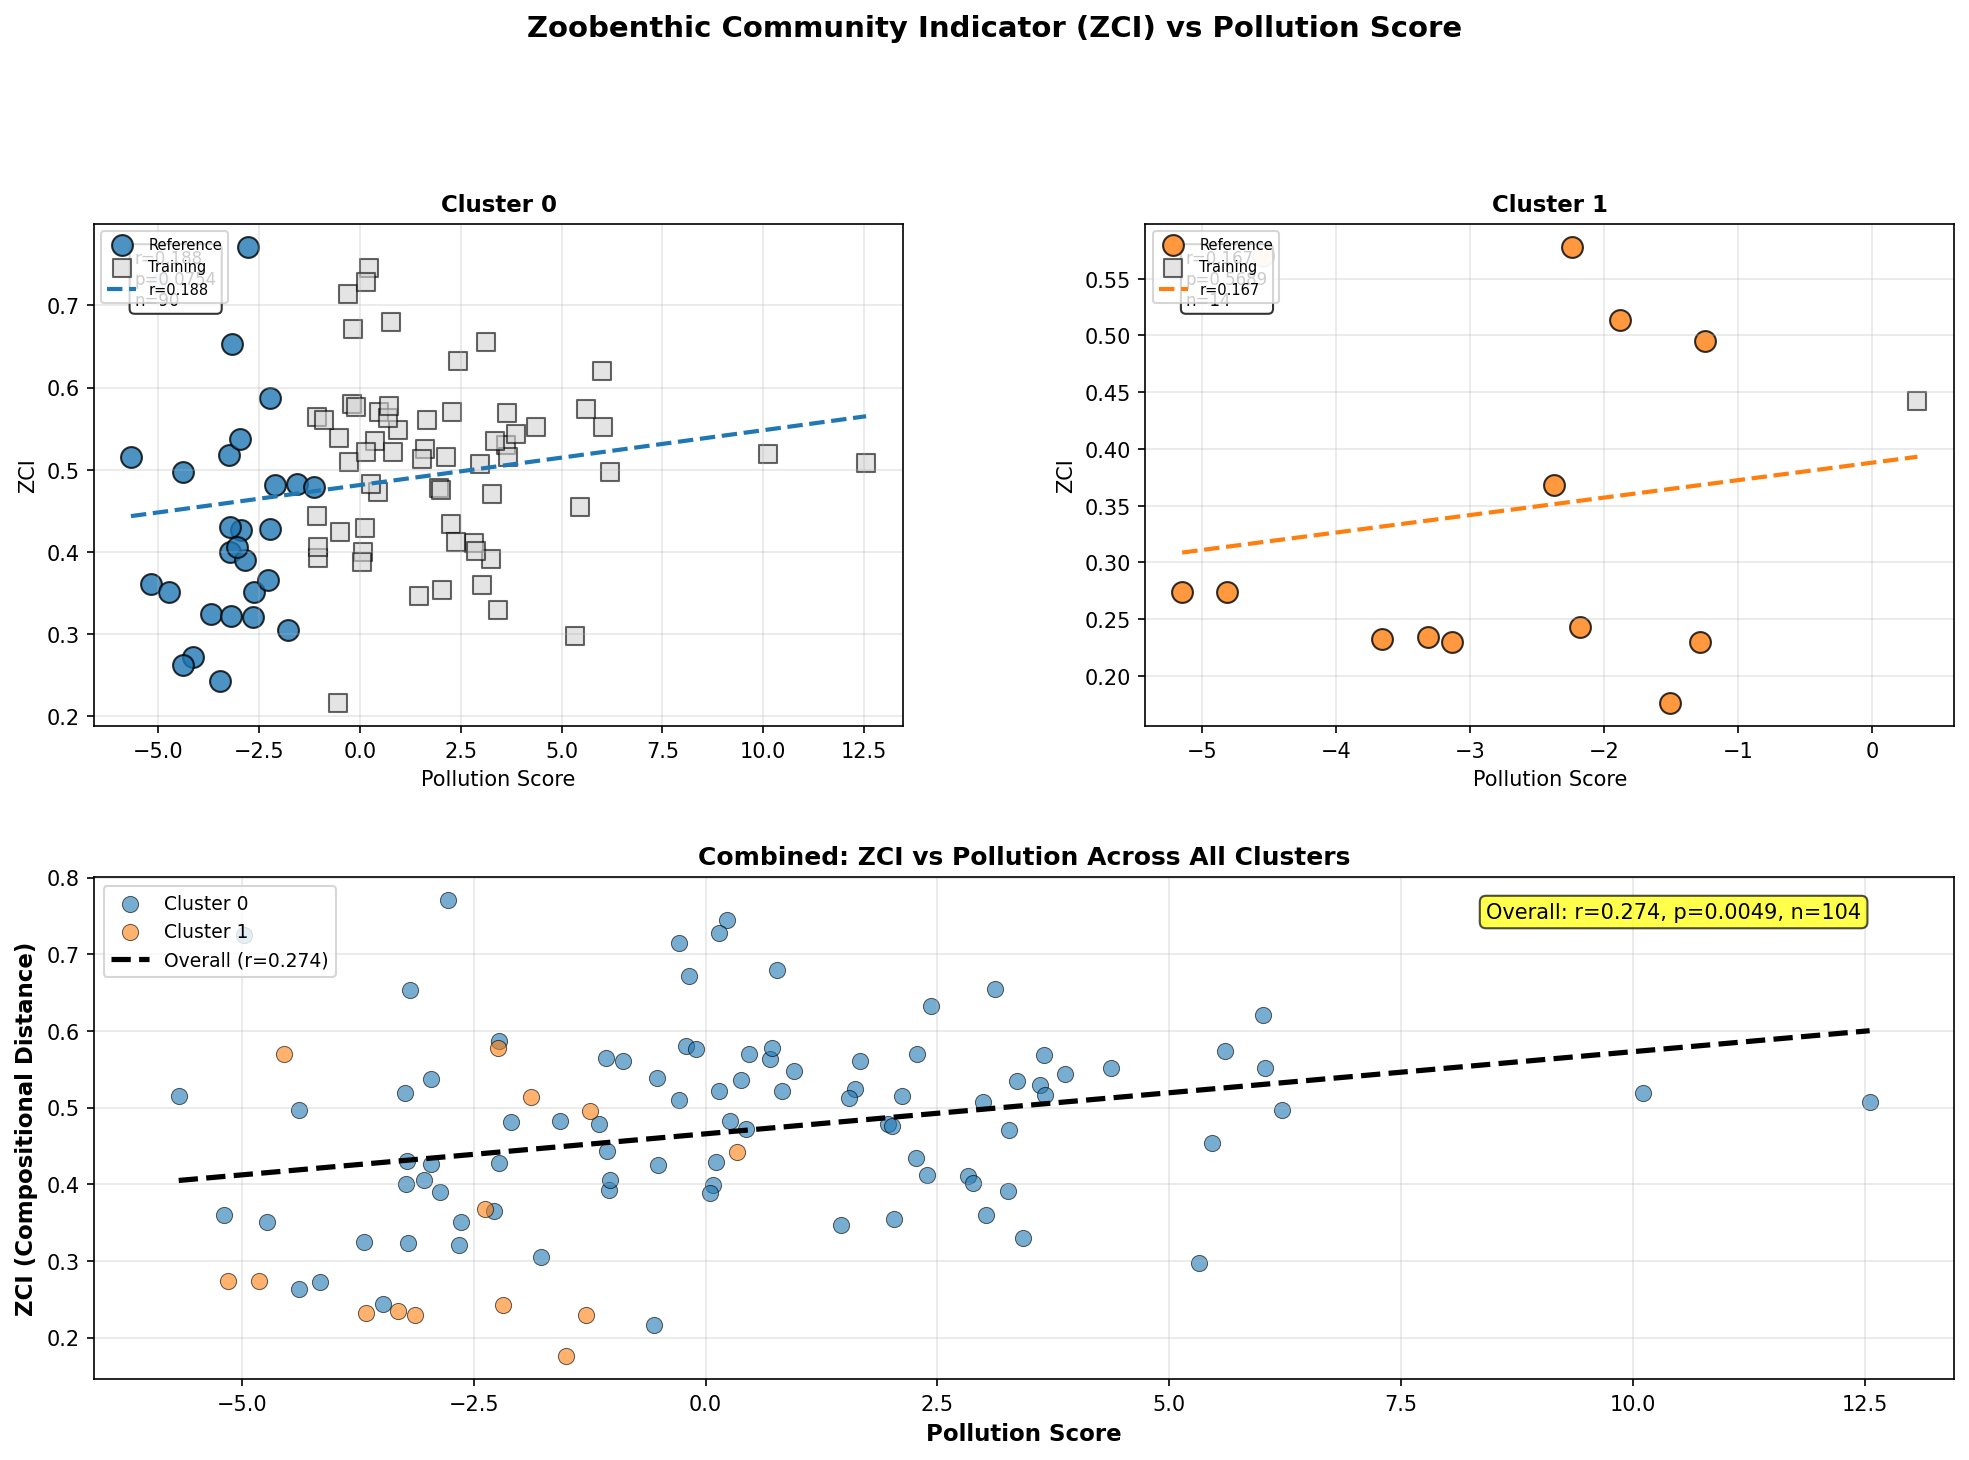

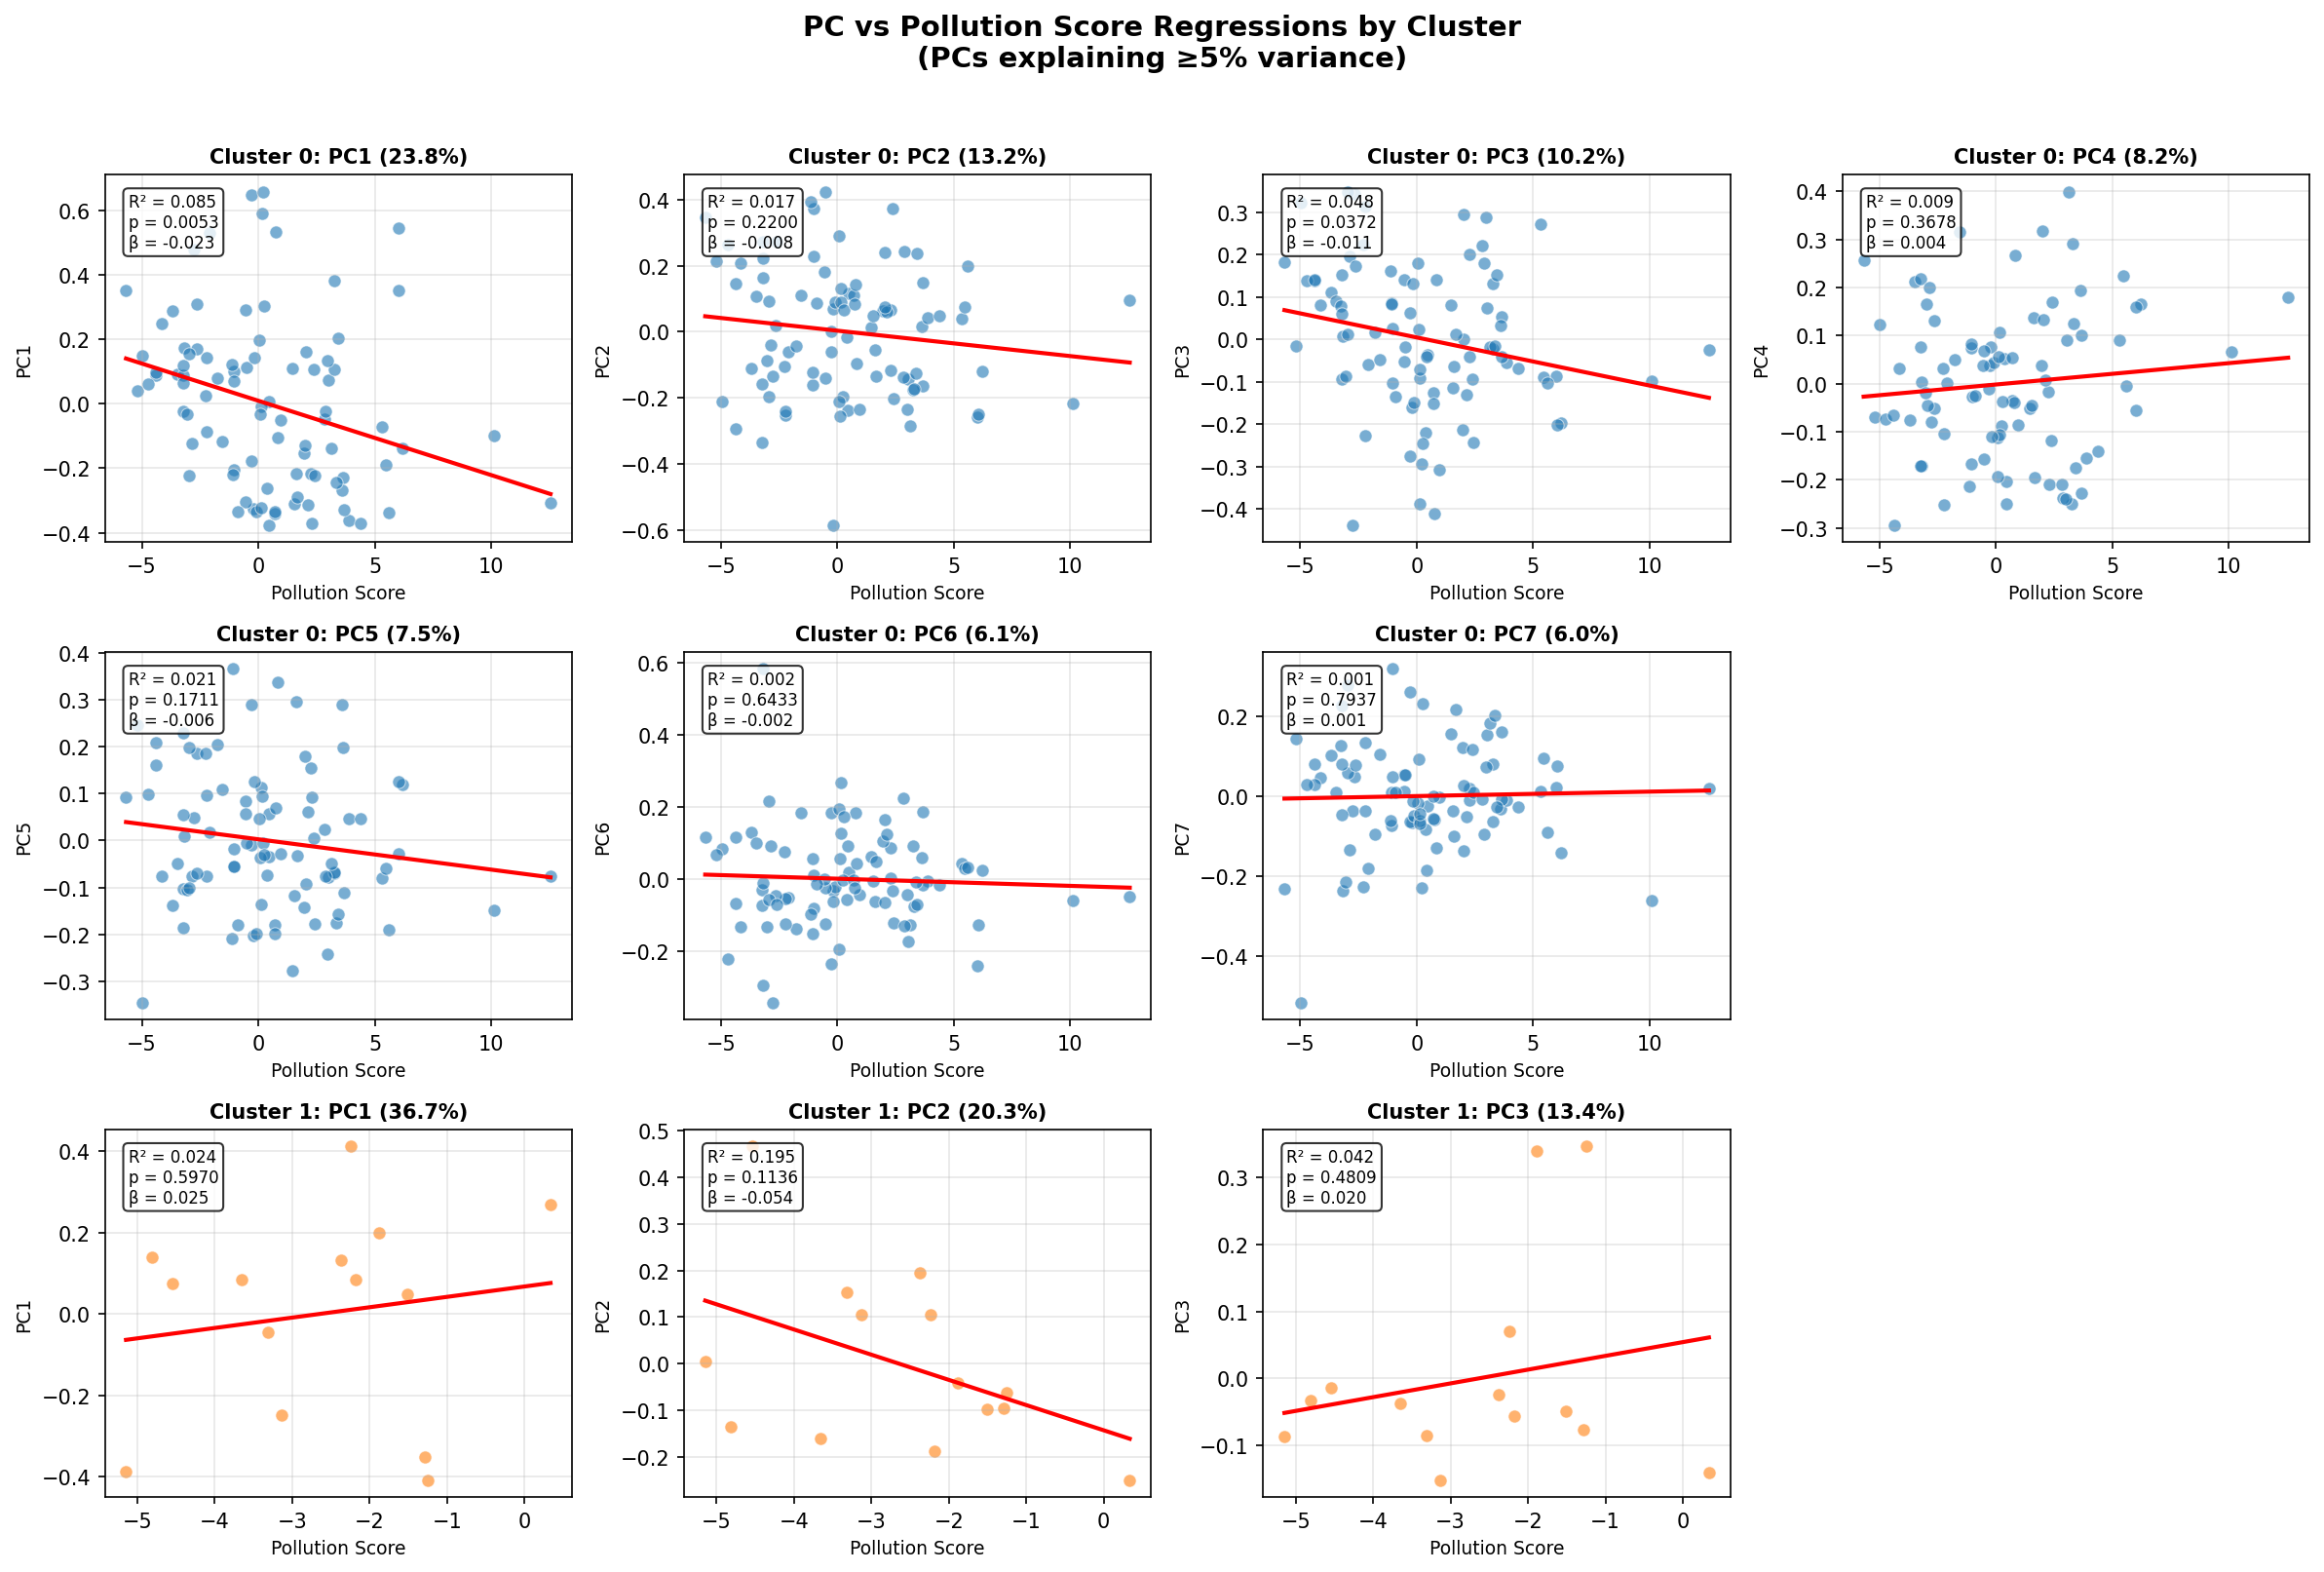

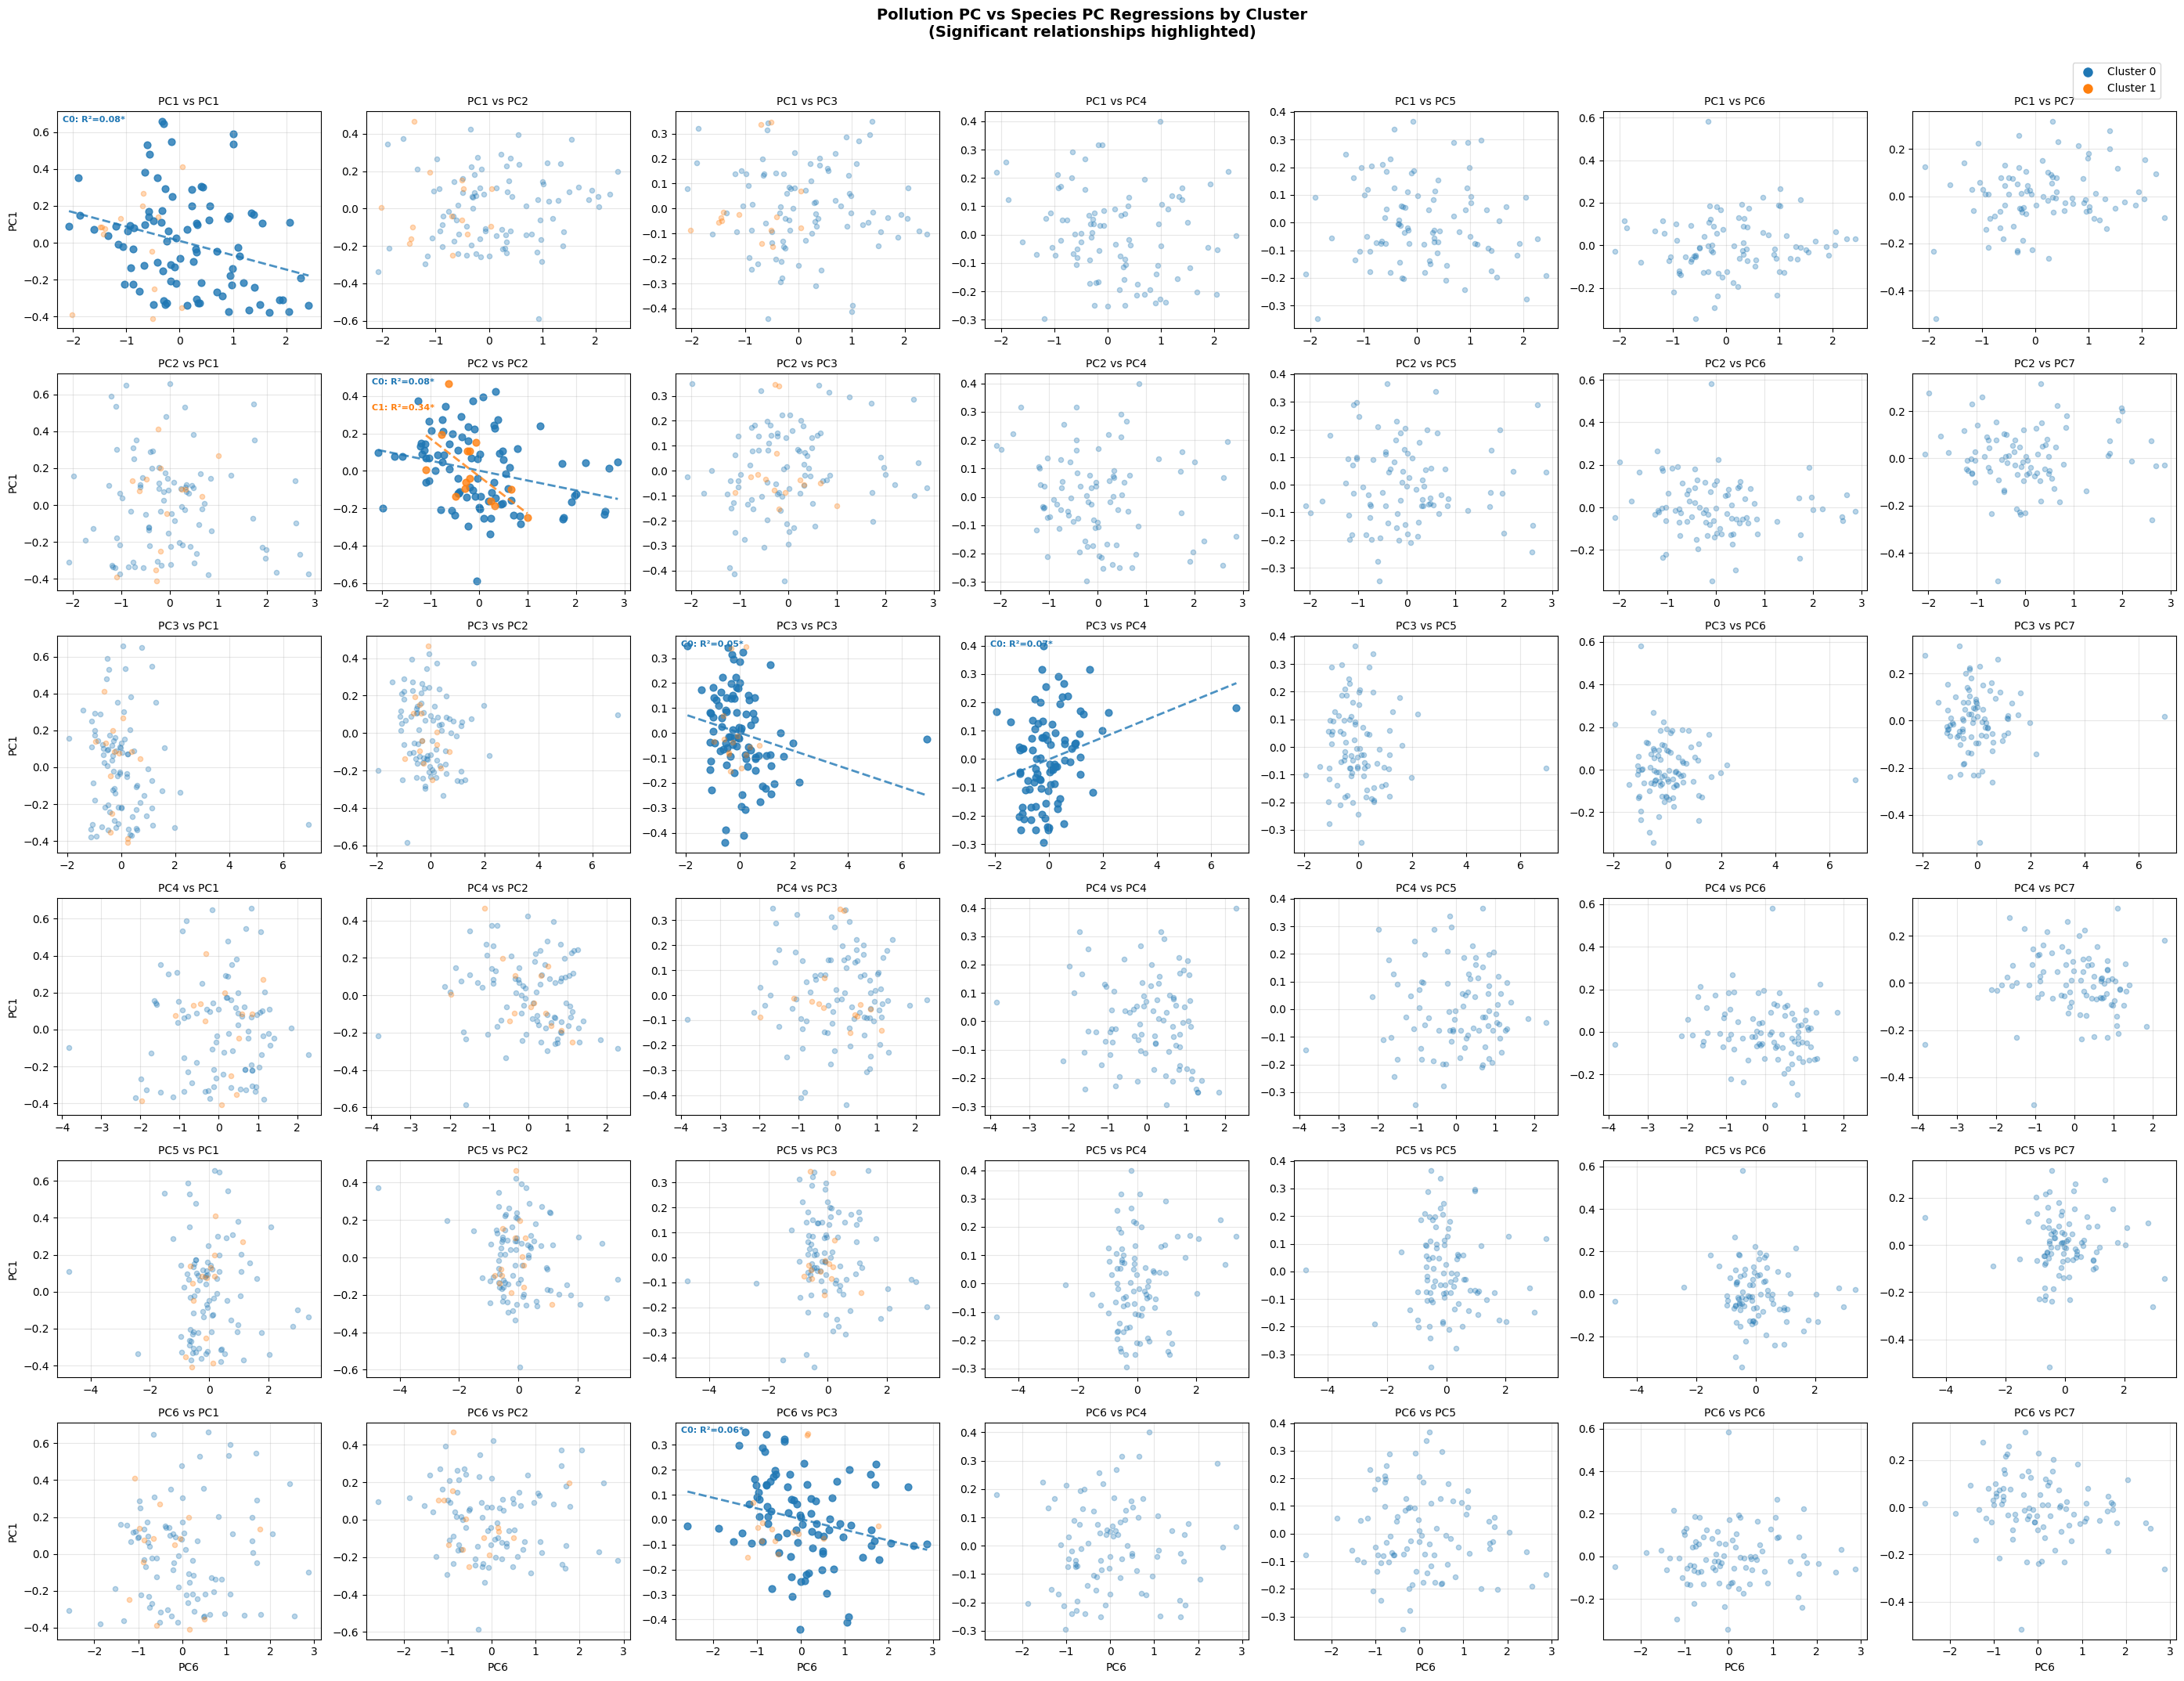

In [291]:
# =============================================================================
# STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)")
print("=" * 80)

cfg_s4 = KEY_PARAMS['stage4']

# Determine save path
save_path_s4 = FIGURE_PATHS[4] if OUTPUT_PARAMS['save_figures'] else None

# Run the refactored pipeline with simplified parameters
stage4_results = community_composition_pipeline(
    raw_data=raw_data_s3,
    multiindex_data=multiindex_data_s3,
    cluster_column=DATA_PARAMS['cluster_column'],
    ref_column=DATA_PARAMS['ref_column'],
    pollution_column=DATA_PARAMS['pollution_column'],
    
    # --- PCA PARAMETERS ---
    training_percentile=cfg_s4['training_percentile'],
    variance_threshold=cfg_s4['variance_threshold'],
    taxa_transformation=cfg_s4['taxa_transformation'],
    
    # --- ZCI PARAMETERS ---
    zci_method=cfg_s4['zci_method'],
    least_pollution_threshold=cfg_s4['least_pollution_threshold'],
    zci_pc_planes=cfg_s4['zci_pc_planes'],
    normalize_pcs=cfg_s4['normalize_pcs'],
    
    # --- REGRESSION PARAMETERS ---
    pc_variance_threshold=cfg_s4['pc_variance_threshold'],
    pollution_pc_prefix=cfg_s4['pollution_pc_prefix'],
    
    # --- VISUALIZATION PARAMETERS ---
    create_taxa_loadings_plot=cfg_s4['create_taxa_loadings_plot'],
    create_pc_loadings_plot=cfg_s4['create_pc_loadings_plot'],
    create_ordination_plot=cfg_s4['create_ordination_plot'],
    create_zci_plot=cfg_s4['create_zci_plot'],
    create_pc_regression_plot=cfg_s4['create_pc_regression_plot'],
    create_pollution_vs_species_pc_plot=cfg_s4['create_pollution_vs_species_pc_plot'],
    create_comprehensive_plot=cfg_s4['create_comprehensive_plot'],
    use_consistent_taxa_order=cfg_s4['use_consistent_taxa_order'],
    
    # --- STYLE PARAMETERS ---
    pc_plane=cfg_s4['pc_plane'],
    top_n_taxa=cfg_s4['top_n_taxa'],
    pc_loadings_top_n_taxa=cfg_s4['pc_loadings_top_n_taxa'],
    pc_loadings_show_values=cfg_s4['pc_loadings_show_values'],
    taxa_loadings_pcs=cfg_s4['taxa_loadings_pcs'],
    taxa_loadings_figsize=cfg_s4['taxa_loadings_figsize'],
    ordination_figsize=cfg_s4['ordination_figsize'],
    zci_figsize=cfg_s4['zci_figsize'],
    
    # --- OUTPUT PARAMETERS ---
    save_path=save_path_s4,
    random_state=cfg_s4['random_state'],
    verbose=KEY_PARAMS['verbose'],
)

# Extract updated data with ZCI and Species PCs
final_raw_data = stage4_results['updated_raw_data']
updated_multiindex_data = stage4_results['updated_multiindex_data']

print(f"\n✓ Stage 4 Complete!")
print(f"  - PCA variance threshold: {cfg_s4['variance_threshold']:.0%}")
print(f"  - ZCI method: {cfg_s4['zci_method']}")
print(f"  - ZCI range: [{final_raw_data['ZCI'].min():.3f}, {final_raw_data['ZCI'].max():.3f}]")
print(f"  - Figures generated: {len([f for f in stage4_results['figures'].values() if f is not None])}")

# Report updated data columns
print(f"\n📊 UPDATED DATA COLUMNS:")
zci_col = 'ZCI' if 'ZCI' in final_raw_data.columns else None
species_pc_cols = [c for c in final_raw_data.columns if c.startswith('Species_PC')]
print(f"  - ZCI column: {'✓' if zci_col else '✗'}")
print(f"  - Species PC columns: {len(species_pc_cols)} columns")
if species_pc_cols:
    print(f"    {species_pc_cols[:3]}..." if len(species_pc_cols) > 3 else f"    {species_pc_cols}")

# Save paths
if OUTPUT_PARAMS['save_figures'] and 'figures' in stage4_results:
    print(f"  - Figures saved to: {save_path_s4}")


---

## Pipeline Summary

Comprehensive summary of the complete pipeline results across all four stages.

In [292]:
# =============================================================================
# VERIFY FINAL UPDATED DATA
# =============================================================================

print("=" * 80)
print("FINAL DATA VERIFICATION")
print("=" * 80)

print("\n🔍 UPDATED_RAW_DATA SUMMARY:")
print(f"   • Shape: {final_raw_data.shape}")
print(f"   • Columns: {len(final_raw_data.columns)}")

# Check key columns
key_cols = ['Pollution_Score', 'clusters', 'if_ref', 'ZCI']
print(f"\n   Key columns:")
for col in key_cols:
    if col in final_raw_data.columns:
        print(f"      ✓ {col}")
    else:
        print(f"      ✗ {col} (MISSING)")

# Check Species PC columns
species_pc_cols = [c for c in final_raw_data.columns if c.startswith('Species_PC')]
print(f"\n   Species PC columns: {len(species_pc_cols)}")
if species_pc_cols:
    for col in sorted(species_pc_cols)[:5]:
        n_valid = final_raw_data[col].notna().sum()
        print(f"      • {col}: {n_valid} values")
    if len(species_pc_cols) > 5:
        print(f"      ... and {len(species_pc_cols) - 5} more")

# Statistics
print(f"\n📊 ZCI STATISTICS:")
print(f"   • Range: [{final_raw_data['ZCI'].min():.4f}, {final_raw_data['ZCI'].max():.4f}]")
print(f"   • Mean: {final_raw_data['ZCI'].mean():.4f}")
print(f"   • Median: {final_raw_data['ZCI'].median():.4f}")
print(f"   • Std Dev: {final_raw_data['ZCI'].std():.4f}")
print(f"   • Valid values: {final_raw_data['ZCI'].notna().sum()} / {len(final_raw_data)}")
# Cluster distribution
print(f"\n🎯 CLUSTER DISTRIBUTION:")
cluster_counts = final_raw_data['clusters'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"   • Cluster {int(cluster_id)}: {count} sites")

print(f"\n🔗 MULTIINDEX_DATA VERIFICATION:")
print(f"   • Shape: {updated_multiindex_data.shape}")
print(f"   • Index levels: {updated_multiindex_data.index.nlevels}")

# Check for ZCI in multiindex
zci_col_name = ("zci_results", "computed", "ZCI")
if zci_col_name in updated_multiindex_data.columns:
    n_valid = updated_multiindex_data[zci_col_name].notna().sum()
    print(f"   ✓ ZCI column present: {n_valid} values")
else:
    print(f"   ✗ ZCI column not found")

# Check for Species PCs in multiindex
species_pc_multiindex = [c for c in updated_multiindex_data.columns 
                         if len(c) >= 3 and 'species_pc' in c[0].lower()]
print(f"   • Species PC columns in multiindex: {len(species_pc_multiindex)}")

print("\n✓ DATA VERIFICATION COMPLETE")
print("=" * 80)

FINAL DATA VERIFICATION

🔍 UPDATED_RAW_DATA SUMMARY:
   • Shape: (104, 80)
   • Columns: 80

   Key columns:
      ✓ Pollution_Score
      ✓ clusters
      ✓ if_ref
      ✓ ZCI

   Species PC columns: 10
      • Species_PC1_Cluster0: 90 values
      • Species_PC1_Cluster1: 14 values
      • Species_PC2_Cluster0: 90 values
      • Species_PC2_Cluster1: 14 values
      • Species_PC3_Cluster0: 90 values
      ... and 5 more

📊 ZCI STATISTICS:
   • Range: [0.1756, 0.7711]
   • Mean: 0.4658
   • Median: 0.4820
   • Std Dev: 0.1296
   • Valid values: 104 / 104

🎯 CLUSTER DISTRIBUTION:
   • Cluster 0: 90 sites
   • Cluster 1: 14 sites

🔗 MULTIINDEX_DATA VERIFICATION:
   • Shape: (104, 80)
   • Index levels: 1
   ✓ ZCI column present: 104 values
   • Species PC columns in multiindex: 10

✓ DATA VERIFICATION COMPLETE


In [293]:
# =============================================================================
# COMPLETE PIPELINE SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("COMPLETE ZCI PIPELINE SUMMARY")
print("=" * 80)

print("\n📊 DATA OVERVIEW:")
print(f"   • Total sites: {len(final_raw_data)}")
print(f"   • Reference sites: {(final_raw_data['if_ref'] == True).sum()}")
print(f"   • Non-reference sites: {(final_raw_data['if_ref'] == False).sum()}")

print("\n🔬 STAGE 1 - CONTAMINATION ASSESSMENT:")
print(f"   • Transform method: {KEY_PARAMS['stage1']['transform_method']}")
print(f"   • PC weights: {KEY_PARAMS['stage1']['pc_weights']}")
print(f"   • Pollution score range: [{final_raw_data['Pollution_Score'].min():.2f}, {final_raw_data['Pollution_Score'].max():.2f}]")

print("\n🌿 STAGE 2 - TAXA ASSEMBLAGE:")
print(f"   • Reference percentile: {KEY_PARAMS['stage2']['reference_percentile']}%")
print(f"   • Species transformation: {KEY_PARAMS['stage2']['species_transformation']}")
print(f"   • Number of clusters: {KEY_PARAMS['stage2']['n_clusters']}")
cluster_dist = final_raw_data[final_raw_data['if_ref'] == True]['clusters'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    print(f"      - Cluster {int(cluster_id)}: {count} reference sites")

print("\n📈 STAGE 3 - RDA + LDA RESULTS:")
print(f"   • RDA permutations: {KEY_PARAMS['stage3']['rda_n_permutations']}")
print(f"   • RDA R²: {stage3_results['rda_results']['rda_model'].fit_.r2:.4f}")
print(f"   • RDA Adjusted R²: {stage3_results['rda_results']['rda_model'].fit_.r2_adj:.4f}")
print(f"   • RDA Global test p-value: {stage3_results['rda_results']['global_test'].p_value:.4f}")
print(f"   • LDA iterations: {KEY_PARAMS['stage3']['lda_n_iterations']}")
print(f"   • LDA Full model accuracy: {stage3_results['lda_results']['accuracy']:.2%}")
print(f"   • LDA CV accuracy: {stage3_results['lda_cv_results']['mean_accuracy']:.2%} ± {stage3_results['lda_cv_results']['std_accuracy']:.2%}")

print("\n🎯 STAGE 4 - COMMUNITY COMPOSITION:")
print(f"   • Taxa transformation: {KEY_PARAMS['stage4']['taxa_transformation']}")
print(f"   • Training percentile: {KEY_PARAMS['stage4']['training_percentile']}%")
print(f"   • ZCI method: {KEY_PARAMS['stage4']['zci_method']}")
print(f"   • Taxa loadings PCs: {KEY_PARAMS['stage4']['taxa_loadings_pcs']}")
print(f"   • ZCI computation PCs: {KEY_PARAMS['stage4']['zci_pc_planes']}")
print(f"   • ZCI range: [{final_raw_data['ZCI'].min():.3f}, {final_raw_data['ZCI'].max():.3f}]")

print("\n📋 FINAL CLUSTER DISTRIBUTION (ALL SITES):")
all_cluster_dist = final_raw_data['clusters'].value_counts().sort_index()
for cluster_id, count in all_cluster_dist.items():
    print(f"   • Cluster {int(cluster_id)}: {count} sites")

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)
print("\nOutputs available:")
print("   • final_raw_data: DataFrame with all computed columns (Pollution_Score, clusters, ZCI)")
print("   • stage1_results: Contamination assessment outputs")
print("   • stage2_results: Taxa assemblage outputs")
print("   • stage3_results: RDA + LDA outputs")
print("   • stage4_results: Community composition outputs")


COMPLETE ZCI PIPELINE SUMMARY

📊 DATA OVERVIEW:
   • Total sites: 104
   • Reference sites: 41
   • Non-reference sites: 63

🔬 STAGE 1 - CONTAMINATION ASSESSMENT:
   • Transform method: log_z_score
   • PC weights: {'PC1': 2.0, 'PC2': 1.0, 'PC3': 2.0, 'PC4': 0.0, 'PC5': 1.0, 'PC6': 1.0}
   • Pollution score range: [-5.68, 12.55]

🌿 STAGE 2 - TAXA ASSEMBLAGE:
   • Reference percentile: 40%
   • Species transformation: hellinger
   • Number of clusters: 2
      - Cluster 0: 28 reference sites
      - Cluster 1: 13 reference sites

📈 STAGE 3 - RDA + LDA RESULTS:
   • RDA permutations: 999
   • RDA R²: 0.1989
   • RDA Adjusted R²: 0.0575
   • RDA Global test p-value: 0.0410
   • LDA iterations: 1000
   • LDA Full model accuracy: 70.73%
   • LDA CV accuracy: 57.82% ± 12.01%

🎯 STAGE 4 - COMMUNITY COMPOSITION:
   • Taxa transformation: hellinger
   • Training percentile: 100.0%
   • ZCI method: least_pollution_threshold
   • Taxa loadings PCs: {0: (1, 2, 3, 4, 5), 1: (1, 2, 3, 4, 5, 6), 2: 

In [294]:
# =============================================================================
# TEST: VERIFY ALL COLUMNS IN UPDATED DATA
# =============================================================================

print("=" * 80)
print("TESTING UPDATED DATA STRUCTURES")
print("=" * 80)

# # Test 1: ZCI Column
# print("\n✓ TEST 1: ZCI Column in updated_raw_data")
# if 'ZCI' in updated_raw_data.columns:
#     zci_stats = updated_raw_data['ZCI'].describe()
#     print(f"   • ZCI found: {len(updated_raw_data['ZCI'].notna())} / {len(updated_raw_data)} sites")
#     print(f"   • Mean: {zci_stats['mean']:.4f}")
#     print(f"   • Std: {zci_stats['std']:.4f}")
#     print(f"   • Min: {zci_stats['min']:.4f}, Max: {zci_stats['max']:.4f}")
# else:
#     print("   ✗ ZCI column not found in updated_raw_data")

# # Test 2: Species PC Columns
# print("\n✓ TEST 2: Species PC Columns in updated_raw_data")
# species_pc_cols = [c for c in updated_raw_data.columns if c.startswith('Species_PC')]
# print(f"   • Found {len(species_pc_cols)} Species PC columns")

if species_pc_cols:
    # Group by cluster
    cluster_pc_groups = {}
    for col in species_pc_cols:
        # Extract cluster from column name (e.g., 'Species_PC1_Cluster0')
        if 'Cluster' in col:
            cluster_id = col.split('Cluster')[1]
            if cluster_id not in cluster_pc_groups:
                cluster_pc_groups[cluster_id] = []
            cluster_pc_groups[cluster_id].append(col)
    
    for cluster_id, cols in sorted(cluster_pc_groups.items()):
        print(f"   • Cluster {cluster_id}: {len(cols)} PCs")
        for col in cols[:3]:
            n_valid = final_raw_data[col].notna().sum()
            mean_val = final_raw_data[col].mean()
            print(f"      - {col}: {n_valid} values, mean={mean_val:.4f}")
        if len(cols) > 3:
            print(f"      ... and {len(cols) - 3} more")

# Test 3: Multiindex Data Structure
print("\n✓ TEST 3: Updated multiindex_data structure")
print(f"   • Shape: {updated_multiindex_data.shape}")
print(f"   • Columns (level 0): {updated_multiindex_data.columns.get_level_values(0).unique().tolist()}")

# Check for ZCI in multiindex
zci_col_name = ("zci_results", "computed", "ZCI")
if zci_col_name in updated_multiindex_data.columns:
    n_zci = updated_multiindex_data[zci_col_name].notna().sum()
    print(f"   • ZCI column in multiindex: {n_zci} values")
else:
    print(f"   • ZCI column not in multiindex with expected structure")

# Test 4: Pollution PC Columns (from Stage 1)
print("\n✓ TEST 4: Pollution PC Columns (from Stage 1)")
pollution_pc_cols = [c for c in final_raw_data.columns if c.startswith('Pollution_PC')]
print(f"   • Found {len(pollution_pc_cols)} Pollution PC columns")
if pollution_pc_cols:
    for col in pollution_pc_cols[:3]:
        n_valid = final_raw_data[col].notna().sum()
        print(f"      - {col}: {n_valid} values")

# Test 5: Cluster Labels (from Stage 3)
print("\n✓ TEST 5: Cluster Labels (from Stage 3)")
n_clusters = final_raw_data['clusters'].nunique()
print(f"   • Number of clusters: {n_clusters}")
cluster_dist = final_raw_data['clusters'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    print(f"      - Cluster {int(cluster_id)}: {count} sites")

# Test 6: Summary Statistics
print("\n✓ TEST 6: Complete Data Summary")
print(f"   • Total sites: {len(final_raw_data)}")
print(f"   • Total columns: {len(final_raw_data.columns)}")
print(f"   • Reference sites: {(final_raw_data['if_ref'] == True).sum()}")
print(f"   • Non-reference sites: {(final_raw_data['if_ref'] == False).sum()}")

# Count different types of columns
pollution_cols = [c for c in final_raw_data.columns if 'Pollution' in c]
species_cols = [c for c in final_raw_data.columns if 'Species' in c]
print(f"\n   Column categories:")
print(f"      - Pollution columns: {len(pollution_cols)}")
print(f"      - Species PC columns: {len(species_cols)}")
print(f"      - Other columns: {len(final_raw_data.columns) - len(pollution_cols) - len(species_cols)}")
print("\n" + "=" * 80)
print("✅ ALL TESTS COMPLETED SUCCESSFULLY!")
print("=" * 80)

TESTING UPDATED DATA STRUCTURES
   • Cluster 0: 7 PCs
      - Species_PC1_Cluster0: 90 values, mean=0.0000
      - Species_PC2_Cluster0: 90 values, mean=0.0000
      - Species_PC3_Cluster0: 90 values, mean=0.0000
      ... and 4 more
   • Cluster 1: 3 PCs
      - Species_PC1_Cluster1: 14 values, mean=-0.0000
      - Species_PC2_Cluster1: 14 values, mean=0.0000
      - Species_PC3_Cluster1: 14 values, mean=0.0000

✓ TEST 3: Updated multiindex_data structure
   • Shape: (104, 80)
   • Columns (level 0): ['2008_results', 'chemical', 'environmental', 'habitat', 'pollution', 'sample_info', 'sites', 'taxa', 'Clusters', 'species_pc', 'zci_results']
   • ZCI column in multiindex: 104 values

✓ TEST 4: Pollution PC Columns (from Stage 1)
   • Found 6 Pollution PC columns
      - Pollution_PC1: 104 values
      - Pollution_PC2: 104 values
      - Pollution_PC3: 104 values

✓ TEST 5: Cluster Labels (from Stage 3)
   • Number of clusters: 2
      - Cluster 0: 90 sites
      - Cluster 1: 14 sites



In [1]:
updated_multiindex_data

NameError: name 'updated_multiindex_data' is not defined

In [296]:
# =============================================================================
# KEY STATISTICAL TABLES
# =============================================================================

print("=" * 80)
print("TABLE 1: RDA Axes Summary")
print("=" * 80)
display(stage3_results['rda_axes_table'])

print("\n" + "=" * 80)
print("TABLE 2: RDA Environmental Terms")
print("=" * 80)
display(stage3_results['rda_terms_table'])

print("\n" + "=" * 80)
print("TABLE 3: LDA Discriminant Axes Summary")
print("=" * 80)
display(stage3_results['lda_axes_table'].round(4))

print("\n" + "=" * 80)
print("TABLE 4: LDA Variable Importance (Wilks' Lambda)")
print("=" * 80)
display(stage3_results['lda_variable_importance_table'].round(4))

TABLE 1: RDA Axes Summary


,Axis,Eigenvalue,Explained (%),Cumulative (%),F-statistic,p-value,Significance
0,RDA1,0.020889,35.055607,35.055607,2.958538,0.151,ns
1,RDA2,0.015437,25.906309,60.961915,2.186377,0.560,ns
2,RDA3,0.011924,20.009650,80.971566,1.688726,0.872,ns
3,RDA4,0.005227,8.771282,89.742848,0.740257,1.000,ns
4,RDA5,0.003760,6.310346,96.053193,0.532565,1.000,ns
5,RDA6,0.002352,3.946807,100.000000,0.333093,1.000,ns



TABLE 2: RDA Environmental Terms


,Environmental Variable,Delta Inertia,F-statistic,p-value,Significance,RDA1 Coefficient,RDA2 Coefficient
4,MPS (Phi),0.528754,1.872162,0.045,*,0.361806,-0.774475
1,Velocity at bottom (m/sec)_Imputed,0.455311,1.612122,0.079,ns,-0.116235,0.529516
5,LOI (%),0.342810,1.213787,0.260,ns,-0.685197,-0.128417
0,Measured Depth (m),0.293460,1.039054,0.401,ns,0.369875,0.124869
2,Water DO Bottom (mg/L),0.244848,0.866935,0.565,ns,0.456255,0.511197
3,Temperature (oC),0.218168,0.772468,0.677,ns,-0.556452,-0.475380



TABLE 3: LDA Discriminant Axes Summary


,Explained (%),Cumulative (%)
Axis,,
LD1,100.0,100.0



TABLE 4: LDA Variable Importance (Wilks' Lambda)


,Delta Wilks' Lambda,F-statistic,p-value,Significance,LD1 Coefficient,LD2 Coefficient
Environmental Variable,,,,,,
LOI (%),0.0462,1.7693,0.1923,ns,-0.5400,0
Temperature (oC),0.0167,0.6397,0.4294,ns,-0.3746,0
Measured Depth (m),0.0047,0.1780,0.6758,ns,0.1601,0
Velocity at bottom (m/sec)_Imputed,0.0030,0.1166,0.7349,ns,-0.1306,0
MPS (Phi),0.0021,0.0811,0.7776,ns,0.1155,0
Water DO Bottom (mg/L),0.0000,0.0003,0.9868,ns,-0.0070,0
